In [31]:
import os
import numpy as np
from numpy import exp, arccos, sin, cos, tan
import matplotlib.pyplot as plt
import matplotlib.colors as   mcolors
from programs.Analysis import Analysis, ResonatorFit, gaussian_fit, Fit, dBm_Watt#, probe_resonator_fit
from programs.datataking import search_datadict_miyamura, search_datadicts

data_path = "D:\\miyamura\\result\\CDK173"
image_path = "D:\\miyamura\\analysis\\images\\CDK173\\"
os.makedirs(image_path, exist_ok=True)

def s11_ge_dp(f, f_r, f_f, k_ex, k_in, chi, g, gamma, phi):
    k_tot = k_ex + k_in
    s11_g = np.cos(phi) + np.exp(1j*phi) * k_ex * (1j*(f-f_r) - gamma/2)/((1j*(f-f_f)-k_tot/2) * (1j*(f-f_r)-gamma/2) + g**2)
    s11_e = np.cos(phi) + np.exp(1j*phi) * k_ex * (1j*(f-(f_r+chi)) - gamma/2)/((1j*(f-f_f)-k_tot/2) * (1j*(f-(f_r+chi))-gamma/2) + g**2)
    return (s11_g/s11_e).conj()
def guess_params_dp(data,x):
    par_ini = {"f_r":10.38111, "f_f":10.38111, "k_ex":0.11, "k_in":0.002, "chi":-5e-3, "g":0.050, "gamma":0, "phi":0,}
    par_max = {"f_r":11, "f_f":11, "k_ex":0.8, "k_in":100e-3, "chi":0, "g":1, "gamma":.3, "phi":2 * np.pi,}
    par_min = {"f_r":9, "f_f":9, "k_ex":0, "k_in":0e-3, "chi":-50e-3, "g":0, "gamma":0, "phi":-2*np.pi,}
    par_vary = {"f_r":1, "f_f":1, "k_ex":1, "k_in":1, "chi":True, "g":1, "gamma":1, "phi":1}
    return par_ini,par_max,par_min,par_vary
def probe_resonator_fit_dp(data, x):
    import lmfit as lmf
    model = lmf.Model(s11_ge_dp, nan_policy='omit')
    params = model.make_params()
    par_ini,par_max,par_min,par_vary=guess_params_dp(data,x)
    for name in params:
        params[name].set(
            value=par_ini[name],  # 初期値
            min=par_min[name],  # 下限値
            max=par_max[name],  # 上限値
            vary=par_vary[name] # パラメータを動かすかどうか
        )
    result=model.fit(data, f=x, params=params, method='leastsq')
    return result

def s11_two(f, fr, ff, ke, ki, g, gamma, alpha, Ed, A):
    top = 1j * (f - ff) - (ki-ke)/2 + g**2 / (1j*(f-fr)-gamma/2)
    bottom =  1j * (f - ff) - (ki+ke)/2 + g**2 / (1j*(f-fr)-gamma/2)
    ideal = np.conj(top / bottom)
    env = A*np.exp(1j*(alpha - 2*np.pi*(f-fr)*Ed))
    return ideal * env
def guess_params_s11two():
    par_ini = {"fr":10.2664, "ff":10.1739, "ke":0.20, "ki":0, "g": 0.082, "gamma":0, "alpha":2.12588100, "Ed":-0.42, "A": 0.0028}
    par_max = {"fr":12, "ff":12, "ke":1, "ki":100e-3, "g":800e-3, "gamma":0.01, "alpha":np.pi, "Ed":100, "A":0.5}
    par_min = {"fr":0, "ff":0, "ke":0, "ki":0, "g":0, "gamma":0, "alpha":-np.pi, "Ed":-100, "A":0}
    par_vary = {"fr":True, "ff":True, "ke":0, "ki":0, "g":True, "gamma":0, "alpha":1, "Ed":1, "A":True}
    return par_ini,par_max,par_min,par_vary
def s11_two_fit(data, x):
    import lmfit as lmf
    model = lmf.Model(s11_two)
    params = model.make_params()
    par_ini,par_max,par_min,par_vary=guess_params_s11two()
    for name in params:
        params[name].set(
            value=par_ini[name],  # 初期値
            min=par_min[name],  # 下限値
            max=par_max[name],  # 上限値
            vary=par_vary[name] # パラメータを動かすかどうか
        )
    result=model.fit(data, f=x, params=params, method='leastsq')
    return result

plt.rcParams['xtick.direction'] = 'in'#xŽ²‚Ì–Ú·ü‚ª“àŒü‚«('in')‚©ŠOŒü‚«('out')‚©‘o•ûŒü‚©('inout')
plt.rcParams['ytick.direction'] = 'in'#yŽ²‚Ì–Ú·ü‚ª“àŒü‚«('in')‚©ŠOŒü‚«('out')‚©‘o•ûŒü‚©('inout')
plt.rcParams['xtick.major.width'] = 0.9#xŽ²Žå–Ú·‚èü‚Ìü•
plt.rcParams['ytick.major.width'] = 0.9#yŽ²Žå–Ú·‚èü‚Ìü•
plt.rcParams['font.size'] = 8 #ƒtƒHƒ“ƒg‚Ì‘å‚«‚³
plt.rcParams['axes.linewidth'] = 0.9# Ž²‚Ìü•edge linewidthBˆÍ‚Ý‚Ì‘¾‚³
plt.rcParams['xtick.top'] = True
plt.rcParams['xtick.bottom'] = True
plt.rcParams['ytick.left'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['lines.linewidth'] = 1
plt.rcParams['lines.markersize'] = 3.5

# CW measurement

## cavity spectrum

In [ ]:
_, datadict = search_datadict_miyamura(data_path, "2024-02-11", acquire_time="130618")
frequency = np.unique(datadict["frequency"]["values"]) / 1e9
s11 = datadict["s11"]["values"]
a = ResonatorFit(s11, frequency)
a.plot(with_fit=True, init=1)
print(a.fit().fit_report())

In [ ]:
from scipy.constants import hbar

def dBm_watt(dbm):
    return 10**(dbm/10) * 1e-3 # W

def photon_num(dbm, kappa, omega_p):
    power = dBm_watt(dbm)
    return kappa / (kappa/2)**2 * power / hbar / omega_p

dbm_at_resonator = (
    -10 # vna power
    -40 # attenuation at room temp.
    -51 # attenuation of wirings inside the fridge
    -20 # added attenuation at MC
)
kappa = 81e6 * 2 * np.pi

print(photon_num(dbm_at_resonator, kappa, 10.0630e9 * 2 * np.pi))

In [ ]:
_, datadict = search_datadict_miyamura(data_path, "2024-04-23", acquire_time="152322", name="spectrum")
frequency = np.unique(datadict["frequency"]["values"]) / 1e9
s11 = datadict["s11"]["values"]
a = s11_two_fit(s11, frequency)
print(a.fit_report())
plt.plot(s11.real, s11.imag, "ko")
plt.plot(a.best_fit.real, a.best_fit.imag, "r--")
plt.plot(a.init_fit.real, a.init_fit.imag, "g--")
plt.show()
plt.plot(frequency, np.angle(s11), "ko")
plt.plot(frequency, np.angle(a.best_fit), "r--")
plt.plot(frequency, np.angle(a.init_fit), "g--")

In [ ]:
_, datadict = search_datadict_miyamura(data_path, "2024-04-27", acquire_time="182000", name="spectrum")
frequency = np.unique(datadict["frequency"]["values"]) / 1e9
s11 = datadict["s11"]["values"]
a = s11_two_fit(s11, frequency)
print(a.fit_report())

plt.plot(s11.real, s11.imag, "ko")
plt.plot(a.best_fit.real, a.best_fit.imag, "r--")
plt.plot(a.init_fit.real, a.init_fit.imag, "g--")
plt.show()
plt.plot(frequency, np.angle(s11), "ko")
plt.plot(frequency, np.angle(a.best_fit), "r--")
plt.plot(frequency, np.angle(a.init_fit), "g--")

In [ ]:
from scipy import sqrt
fr = 10.068
fp = 10.084
delta = fr - fp
kappa = 0.402
g = 0.08467
print(np.real(sqrt((delta+1j*kappa/2)**2 + 4*g**2)))
print(np.imag(sqrt((delta+1j*kappa/2)**2 + 4*g**2)))
print(f"freq {(fr+fp)/2} +- {np.real(sqrt((delta+1j*kappa/2)**2 + 4*g**2))/2}")
print(f"kappa {kappa/2} +- {np.imag(sqrt((delta+1j*kappa/2)**2 + 4*g**2))}")

In [ ]:
from scipy import sqrt
fr = 10.06812
fp = 10.0972524
delta = fr - fp
kappa = 0.3575
g = 0.0798
print(np.real(sqrt((delta+1j*kappa/2)**2 + 4*g**2)))
print(np.imag(sqrt((delta+1j*kappa/2)**2 + 4*g**2)))
print(f"freq {(fr+fp)/2} +- {np.real(sqrt((delta+1j*kappa/2)**2 + 4*g**2))/2}")
print(f"kappa {kappa/2} +- {np.imag(sqrt((delta+1j*kappa/2)**2 + 4*g**2))}")

In [ ]:
_, datadict = search_datadict_miyamura(data_path, "2024-01-01", acquire_time="145035", name="spectrum")
frequency = np.unique(datadict["frequency"]["values"]) / 1e9
s11 = datadict["s11"]["values"]
a = s11_two_fit2(s11, frequency)
print(a.fit_report())
plt.plot(s11.real, s11.imag, "ko")
plt.plot(a.best_fit.real, a.best_fit.imag, "r--")
plt.plot(a.init_fit.real, a.init_fit.imag, "g--")
plt.show()
plt.plot(frequency, np.angle(s11), "ko")
plt.plot(frequency, np.angle(a.best_fit), "r--")
plt.plot(frequency, np.angle(a.init_fit), "g--")

In [ ]:
from scipy import sqrt
fr = 10.063886
fp = 10.100644
delta = fr - fp
kappa =0.25301775
g = 0.057467
print(np.real(sqrt((delta+1j*kappa/2)**2 + 4*g**2)))
print(np.imag(sqrt((delta+1j*kappa/2)**2 + 4*g**2)))
print(f"freq {(fr+fp)/2} +- {np.real(sqrt((delta+1j*kappa/2)**2 + 4*g**2))/2}")
print(f"kappa {kappa/2} +- {np.imag(sqrt((delta+1j*kappa/2)**2 + 4*g**2))}")

## ac stark shift

In [ ]:
_, datadict = search_datadict_miyamura(data_path, "2024-02-11", acquire_time="133636", name="freq_sweep")
frequency = np.unique(datadict["frequency"]["values"])
vna_freq = np.unique(datadict["vna_freq"]["values"])
vna_power = np.unique(datadict["vna_power"]["values"])
s11 = datadict["s11"]["values"].reshape(len(vna_freq), len(vna_power), len(frequency))

from scipy.constants import h
def shift_per_power(f, f_r, kappa, chi, alpha):
    return alpha * kappa * chi / ((f-f_r)**2 + (kappa / 2)**2) / h / f # Hz / Watt
def shift_per_power_fit(data, x):
    import lmfit as lmf
    model = lmf.Model(shift_per_power)
    params = model.make_params()
    par_ini = {"f_r":10.063e9, "kappa":0.0834e9, "chi":-5.17e6, "alpha":1}
    par_max = {"f_r":np.inf, "kappa":1e9, "chi":10e6, "alpha":np.inf}
    par_min = {"f_r":0, "kappa":0, "chi":-10e6, "alpha":-np.inf}
    par_vary = {"f_r":True, "kappa":False, "chi":False, "alpha":True}
    for name in params:
        params[name].set(
            value=par_ini[name],  # 初期値
            min=par_min[name],  # 下限値
            max=par_max[name],  # 上限値
            vary=par_vary[name] # パラメータを動かすかどうか
        )
    result=model.fit(data, f=x, params=params, method='leastsq')
    return result

print(s11.shape)
# fig = plt.figure(figsize=(2 * len(vna_power), 2 * len(vna_freq)))
result = []
for i, vna_f in enumerate(vna_freq):
    res_i = []
    for j, power in enumerate(vna_power):
        # ax = fig.add_subplot(len(vna_power), len(vna_freq), i+j*len(vna_freq)+1)
        S11 = Analysis(s11[i][j], frequency).pca()
        res = Fit(S11, frequency).lorentz_fit()
        # ax.plot(frequency, S11)
        # ax.plot(frequency, res.best_fit)
        res_i.append(res.params.valuesdict()["center"])
    a = Analysis(s11[i], frequency, dBm_Watt(vna_power))
    # a.plot(show=False, labels=["Drive freq", "power (W)"])
    if i==0:
        powers = vna_power[1:] ;res_i = res_i[1:]
    else :powers = vna_power
    # plt.plot(res_i, dBm_Watt(powers), "ro")
    # plt.show()
    result.append(Fit(res_i, dBm_Watt(powers)).linear_fit().params.valuesdict()["slope"])
res = shift_per_power_fit(result, vna_freq)
plt.plot(vna_freq, result, "ko")
plt.plot(vna_freq, res.best_fit, "r--")
# plt.plot(vna_freq, res.init_fit, "g--")
print(res.fit_report())
print(10 * np.log10(res.params.valuesdict()["alpha"]) - (-50-20))

# plt.subplots_adjust()

In [ ]:
_, datadict = search_datadict_miyamura(data_path, "2024-01-09", acquire_time="174105", name="freq_sweep")
frequency = np.unique(datadict["frequency"]["values"])
vna_freq = np.unique(datadict["vna_freq"]["values"])
vna_power = np.unique(datadict["vna_power"]["values"])
s11 = datadict["s11"]["values"].reshape(len(vna_freq), len(vna_power), len(frequency))

from scipy.constants import h
def shift_per_power(f, f_r, kappa, chi, alpha):
    return alpha * kappa * chi / ((f-f_r)**2 + (kappa / 2)**2) / h / f # Hz / Watt
def shift_per_power_fit(data, x):
    import lmfit as lmf
    model = lmf.Model(shift_per_power)
    params = model.make_params()
    par_ini = {"f_r":10.063e9, "kappa":0.0834e9, "chi":-5.17665e6, "alpha":1}
    par_max = {"f_r":np.inf, "kappa":1e9, "chi":10e6, "alpha":np.inf}
    par_min = {"f_r":0, "kappa":0, "chi":-10e6, "alpha":-np.inf}
    par_vary = {"f_r":1, "kappa":1, "chi":False, "alpha":True}
    for name in params:
        params[name].set(
            value=par_ini[name],  # 初期値
            min=par_min[name],  # 下限値
            max=par_max[name],  # 上限値
            vary=par_vary[name] # パラメータを動かすかどうか
        )
    result=model.fit(data, f=x, params=params, method='leastsq')
    return result

print(s11.shape)
# fig = plt.figure(figsize=(2 * len(vna_power), 2 * len(vna_freq)))
result = []
for i, vna_f in enumerate(vna_freq):
    res_i = []
    for j, power in enumerate(vna_power):
        # ax = fig.add_subplot(len(vna_power), len(vna_freq), i+j*len(vna_freq)+1)
        S11 = Analysis(s11[i][j], frequency).pca()
        res = Fit(S11, frequency).lorentz_fit()
        # ax.plot(frequency, S11)
        # ax.plot(frequency, res.best_fit)
        res_i.append(res.params.valuesdict()["center"])
    a = Analysis(s11[i], frequency, dBm_Watt(vna_power))
    # a.plot(show=False, labels=["Drive freq", "power (W)"])
    if i==0:
        powers = vna_power[1:] ;res_i = res_i[1:]
    else :powers = vna_power
    # plt.plot(res_i, dBm_Watt(powers), "ro")
    # plt.show()
    result.append(Fit(res_i, dBm_Watt(powers)).linear_fit().params.valuesdict()["slope"])
res = shift_per_power_fit(result, vna_freq)
plt.plot(vna_freq, result, "ko")
plt.plot(vna_freq, res.best_fit, "r--")
# plt.plot(vna_freq, res.init_fit, "g--")
print(res.fit_report())
print(10 * np.log10(res.params.valuesdict()["alpha"]) - (-50-20))

# plt.subplots_adjust()

## JPA spectrum

(array([100], dtype=int64),)


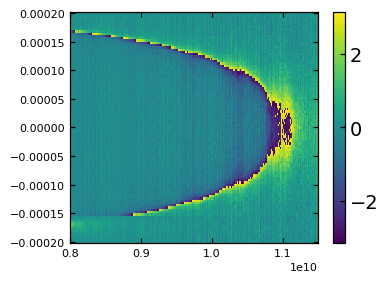

d:\miyamura\analysis\programs\Analysis.py:300: RuntimeWarning: divide by zero encountered in divide
  a = a / np.sqrt((a[1]**2 + a[2]**2 -4*a[0]*a[3]))


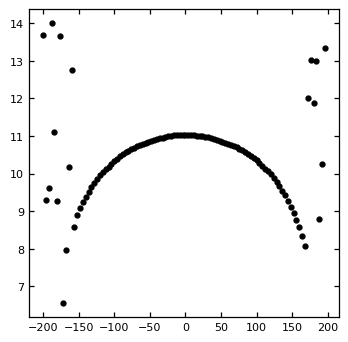

In [33]:
_, datadict = search_datadict_miyamura(data_path, "2025-02-05", acquire_time="191629")
current = np.unique(datadict["current"]["values"])
frequency = np.unique(datadict["frequency"]["values"])
s11 = datadict["s11"]["values"].reshape(len(current), len(frequency))
base_s11 = s11[-1]
print(np.where(current==2e-4))

for i in range(len(s11)):
    s11[i] /= base_s11
a = Analysis((np.angle(s11)), frequency, current)
a.plot()
f_r = []
for i, s in enumerate(s11):
    delete = []
    try:
        a = ResonatorFit(s, frequency / 1e9)
        # a.plot(with_fit=True, init=1)
        f_r.append(a.fit().params.valuesdict()["f_r"])
    except: delete.append(i)
plt.figure(figsize=(4, 4))
plt.plot(np.delete(current, delete)*1e6, f_r, "ko")
plt.show()

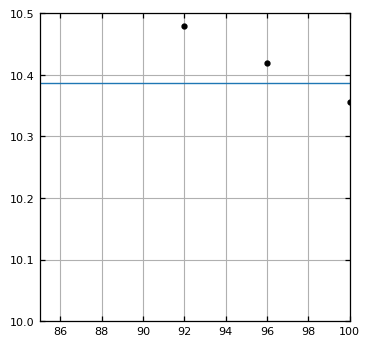

In [35]:
plt.figure(figsize=(4, 4))
plt.plot(np.delete(current, delete)*1e6, f_r, "ko")
plt.ylim(10.0, 10.5)
plt.xlim(85, 100)
# plt.ylim(9.3, 9.9)
# plt.xlim(-120, -90)
plt.axhline(10.387,)
plt.grid(which="both")
plt.show()

(array([100], dtype=int64),)


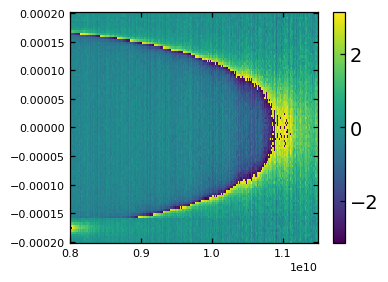

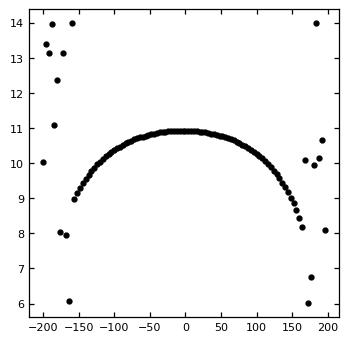

In [36]:
_, datadict = search_datadict_miyamura(data_path, "2025-02-05", acquire_time="195126")
current = np.unique(datadict["current"]["values"])
frequency = np.unique(datadict["frequency"]["values"])
s11 = datadict["s11"]["values"].reshape(len(current), len(frequency))
base_s11 = s11[-1]
print(np.where(current==2e-4))

for i in range(len(s11)):
    s11[i] /= base_s11
a = Analysis((np.angle(s11)), frequency, current)
a.plot()
f_r = []
for i, s in enumerate(s11):
    delete = []
    try:
        a = ResonatorFit(s, frequency / 1e9)
        # a.plot(with_fit=True, init=1)
        f_r.append(a.fit().params.valuesdict()["f_r"])
    except: delete.append(i)
plt.figure(figsize=(4, 4))
plt.plot(np.delete(current, delete)*1e6, f_r, "ko")
plt.show()

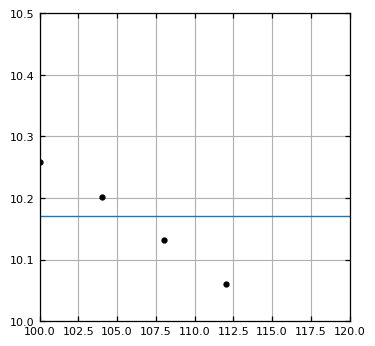

In [37]:
plt.figure(figsize=(4, 4))
plt.plot(np.delete(current, delete)*1e6, f_r, "ko")
plt.ylim(10.0, 10.5)
# plt.xlim(85, 100)
# plt.ylim(9.3, 9.9)
plt.xlim(100, 120)
plt.axhline(10.17,)
plt.grid(which="both")
plt.show()

In [ ]:
_, datadict = search_datadict_miyamura(data_path, "2024-08-13", acquire_time="151802")
current = np.unique(datadict["current"]["values"])
frequency = np.unique(datadict["frequency"]["values"])
s11 = datadict["s11"]["values"].reshape(len(current), len(frequency))
base_s11 = s11[-1]
print(np.where(current==2e-4))

for i in range(len(s11)):
    s11[i] /= base_s11
a = Analysis((np.angle(s11)), frequency, current)
a.plot()
f_r = []
for i, s in enumerate(s11):
    delete = []
    try:
        a = ResonatorFit(s, frequency / 1e9)
        # a.plot(with_fit=True, init=1)
        f_r.append(a.fit().params.valuesdict()["f_r"])
    except: delete.append(i)
plt.figure(figsize=(4, 4))
plt.plot(np.delete(current, delete)*1e6, f_r, "ko")
plt.show()

In [ ]:
plt.figure(figsize=(4, 4))
plt.plot(np.delete(current, delete)*1e6, f_r, "ko")
# plt.ylim(10.0, 10.5)
# plt.xlim(85, 100)
plt.ylim(9.3, 9.5)
plt.xlim(100, 120)
plt.xlim(-10, 10)
plt.axhline(9.381212,)
plt.grid(which="both")
plt.show()

## JPA saturation


In [ ]:
_, datadict = search_datadict_miyamura(data_path, "2024-07-27", acquire_time="164632", name="saturation_amp_sweep")
amplitude = np.unique(datadict["amplitude"]["values"])
power = np.unique(datadict["power"]["values"])
s11 = datadict["s11"]["values"].reshape(len(amplitude), len(power))
base_s11 = s11.copy()[0]

for i in range(len(s11)):
    s11[i] = s11[i] / base_s11
    plt.plot(power, 20*np.log10(abs(s11[i])), label=f"{amplitude[i]}")
plt.legend()
plt.show()

## JPA gain

In [ ]:
_, datadict = search_datadict_miyamura(data_path, "2024-07-27", acquire_time="164151", name="amp_sweep")
amplitude = np.unique(datadict["amplitude"]["values"])
frequency = np.unique(datadict["frequency"]["values"]) / 1e9
gain = datadict["gain"]["values"].reshape(len(amplitude), len(frequency))
plt.figure(figsize=(4, 4))
for i, a in enumerate(amplitude):
    plt.plot(frequency, gain[i], label=f"{a} V")
plt.ylim(0, 33)
plt.legend(bbox_to_anchor=(1, 1), loc='upper left')
plt.xlabel("Probe frequency (GHz)") ;plt.ylabel("Gain (dB)")
plt.show()

In [ ]:
_, datadict = search_datadict_miyamura(data_path, "2023-09-05", acquire_time="190145", name="amp_sweep")
amplitude = np.unique(datadict["amplitude"]["values"])
frequency = np.unique(datadict["frequency"]["values"]) / 1e9
gain = datadict["gain"]["values"].reshape(len(amplitude), len(frequency))
plt.figure(figsize=(4, 4))
for i, a in enumerate(amplitude):
    plt.plot(frequency, gain[i], label=f"{a} V")
plt.ylim(0, 40)
plt.legend(bbox_to_anchor=(1, 1), loc='upper left')
plt.show()

In [ ]:
_, datadict = search_datadict_miyamura(data_path, "2023-09-05", acquire_time="184844", name="amp_sweep")
amplitude = np.unique(datadict["amplitude"]["values"])
frequency = np.unique(datadict["frequency"]["values"]) / 1e9
gain = datadict["gain"]["values"].reshape(len(amplitude), len(frequency))
plt.figure(figsize=(4, 4))
for i, a in enumerate(amplitude):
    plt.plot(frequency, gain[i], label=f"{a} V")
plt.ylim(0, 40)
plt.legend(bbox_to_anchor=(1, 1), loc='upper left')
plt.show()

In [ ]:
_, datadict = search_datadict_miyamura(data_path, "2023-09-05", acquire_time="185143", name="amp_sweep")
amplitude = np.unique(datadict["amplitude"]["values"])
frequency = np.unique(datadict["frequency"]["values"]) / 1e9
gain = datadict["gain"]["values"].reshape(len(amplitude), len(frequency))
plt.figure(figsize=(4, 4))
for i, a in enumerate(amplitude):
    plt.plot(frequency, gain[i], label=f"{a} V")
plt.ylim(0, 40)
plt.legend(bbox_to_anchor=(1, 1), loc='upper left')
plt.show()

In [ ]:
_, datadict = search_datadict_miyamura(data_path, "2023-09-05", acquire_time="185811", name="amp_sweep")
amplitude = np.unique(datadict["amplitude"]["values"])
frequency = np.unique(datadict["frequency"]["values"]) / 1e9
gain = datadict["gain"]["values"].reshape(len(amplitude), len(frequency))
plt.figure(figsize=(4, 4))
for i, a in enumerate(amplitude):
    plt.plot(frequency, gain[i], label=f"{a} V")
plt.ylim(0, 40)
plt.legend(bbox_to_anchor=(1, 1), loc='upper left')
plt.show()

# TD measurement

## ge pi pulse

### rabi\

[-0.0020501190384272865, 0.05591533968882235, 0.11388079841607197, 0.1718462571433216, 0.22981171587057123, 0.2877771745978208, 0.34574263332507055, 0.4037080920523201, 0.4616735507795698, 0.5196390095068194, 0.5776044682340691, 0.6355699269613186, 0.6935353856885683, 0.7515008444158179, 0.8094663031430676, 0.8674317618703171, 0.9253972205975668]
[[Model]]
    Model(sine)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 25
    # data points      = 81
    # variables        = 3
    chi-square         = 1.3009e-06
    reduced chi-square = 1.6678e-08
    Akaike info crit   = -1447.70116
    Bayesian info crit = -1440.51781
    R-squared          = 0.98227807
[[Variables]]
    amplitude:  0.00132742 +/- 2.0191e-05 (1.52%) (init = 0.001186789)
    frequency:  54.1976674 +/- 0.05314229 (0.10%) (init = 55.85054)
    shift:      1.68190800 +/- 0.03066206 (1.82%) (init = 0.5711987)
[[Correlations]] (unreported correlations are < 0.100)
    C(frequency, shift) = -0.86

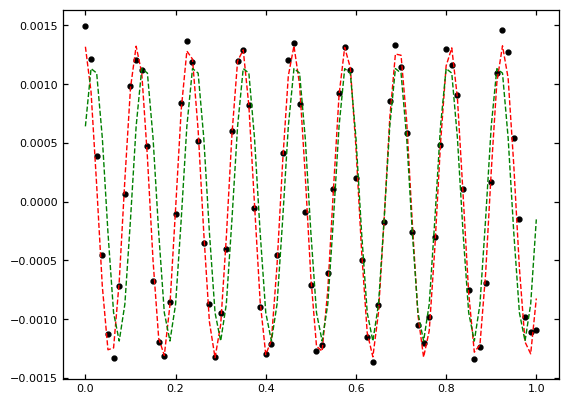

In [38]:
_, datadict = search_datadict_miyamura(data_path, "2025-02-06",
                                        acquire_time="124727",
                                        name="ge_pi_amp")
time = datadict["amplitude"]["values"]
s11 = datadict["s11"]["values"]
a = Analysis(s11, time)
res = a.fit_1d(kind="rabi")
print(res.fit_report())
plt.plot(time, a.pca(), "ko")
plt.plot(time, res.best_fit, "r--")
plt.plot(time, res.init_fit, "g--")
plt.show()

### ramsey

[[Model]]
    Model(modelf)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 31
    # data points      = 50
    # variables        = 5
    chi-square         = 2.5102e-07
    reduced chi-square = 5.5782e-09
    Akaike info crit   = -945.488097
    Bayesian info crit = -935.927982
    R-squared          = 0.95023445
[[Variables]]
    T2:    8283.75118 +/- 4113.98776 (49.66%) (init = 4101.874)
    freq:  0.00197923 +/- 9.5149e-06 (0.48%) (init = 0.002)
    A:     4.9320e-04 +/- 3.1549e-05 (6.40%) (init = 0.0005054562)
    phi:   0.37478086 +/- 0.06364282 (16.98%) (init = 0.2472427)
    off:   4.6064e-06 +/- 1.0779e-05 (234.00%) (init = -7.589415e-21)
[[Correlations]] (unreported correlations are < 0.100)
    C(freq, phi) = -0.8470
    C(T2, A)     = -0.8449
    C(freq, off) = -0.1984
    C(phi, off)  = +0.1752


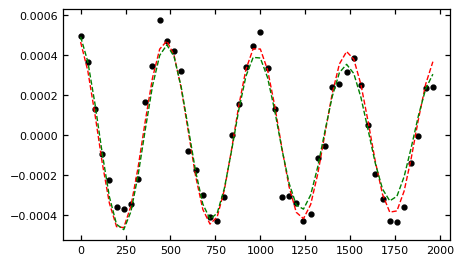

In [21]:
_, datadict = search_datadict_miyamura(data_path, "2025-02-05", 
                                       acquire_time="173917", name="ramsey")
time = datadict["delay"]["values"]
s11 = datadict["s11"]["values"]
a = Analysis(s11, time)
res = a.fit_1d(kind="ramsey")
print(res.fit_report())
plt.figure(figsize=(5, 3))
plt.plot(time, a.pca(), "ko")
plt.plot(time, res.best_fit, "r--")
plt.plot(time, res.init_fit, "g--")
plt.show()

[[Model]]
    Model(modelf)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 37
    # data points      = 50
    # variables        = 5
    chi-square         = 9.0999e-09
    reduced chi-square = 2.0222e-10
    Akaike info crit   = -1111.35110
    Bayesian info crit = -1101.79098
    R-squared          = 0.57938040
[[Variables]]
    T2:    3368.99033 +/- 2635.62269 (78.23%) (init = 10047.29)
    freq:  0.00437191 +/- 3.4927e-05 (0.80%) (init = 0.0045)
    A:     2.9438e-05 +/- 6.5920e-06 (22.39%) (init = 4.181737e-05)
    phi:  -2.04493842 +/- 0.21152998 (10.34%) (init = -2.755407)
    off:  -5.6544e-07 +/- 2.0171e-06 (356.72%) (init = -4.743385e-22)
[[Correlations]] (unreported correlations are < 0.100)
    C(T2, A)     = -0.8235
    C(freq, phi) = -0.8094


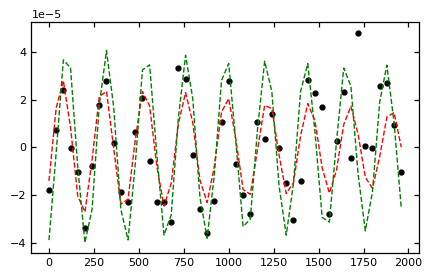

In [5]:
_, datadict = search_datadict_miyamura(data_path, "2025-02-04", 
                                       acquire_time="210543", name="ramsey")
time = datadict["delay"]["values"]
s11 = datadict["s11"]["values"]
a = Analysis(s11, time)
res = a.fit_1d(kind="ramsey")
print(res.fit_report())
plt.figure(figsize=(5, 3))
plt.plot(time, a.pca(), "ko")
plt.plot(time, res.best_fit, "r--")
plt.plot(time, res.init_fit, "g--")
plt.show()

### Drag pi

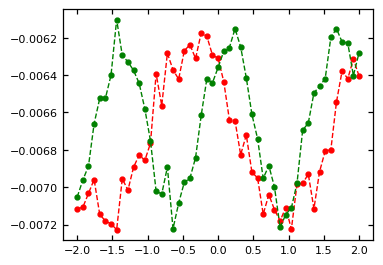

[-2.158946992469509, -1.388430548873681, -0.6179141052778533, 0.1526023383179745, 0.9231187819138023]
[[Model]]
    Model(sine)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 21
    # data points      = 51
    # variables        = 3
    chi-square         = 7.1042e-07
    reduced chi-square = 1.4800e-08
    Akaike info crit   = -916.550914
    Bayesian info crit = -910.755437
    R-squared          = 0.96591765
[[Variables]]
    amplitude:  8.9563e-04 +/- 2.4314e-05 (2.71%) (init = 0.0007135792)
    frequency:  4.07725582 +/- 0.02232053 (0.55%) (init = 4.619989)
    shift:      4.09019021 +/- 0.02675943 (0.65%) (init = 3.998391)


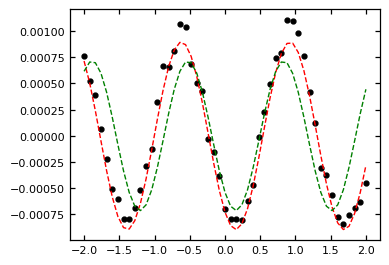

In [23]:
plt.figure(figsize=(4,3))
_, datadict = search_datadict_miyamura(data_path, "2025-02-05", acquire_time="174137", name="drag")
time = datadict["beta"]["values"]
s11 = datadict["s11"]["values"]
plt.plot(time, s11.real, "ro--")
# _, datadict = search_datadict_miyamura(data_path, "2025-02-05", acquire_time="132316", name="drag")
# time = datadict["beta"]["values"]
# s11 = datadict["s11"]["values"]
# plt.plot(time, s11.real, "bo--")
_, datadict = search_datadict_miyamura(data_path, "2025-02-05", acquire_time="174222", name="drag")
time = datadict["beta"]["values"]
s11 = datadict["s11"]["values"]
plt.plot(time, s11.real, "go--")
plt.show()

plt.figure(figsize=(4,3))
a = Analysis(s11, time)
res = a.fit_1d(kind="rabi")
print(res.fit_report())
plt.plot(time, a.pca(), "ko")
plt.plot(time, res.best_fit, "r--")
plt.plot(time, res.init_fit, "g--")
plt.show()

### Drag half pi

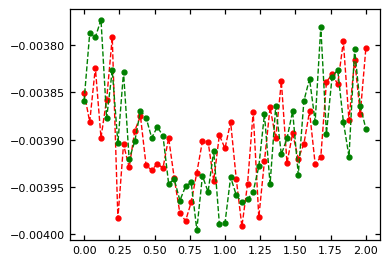

[0.07847023879165359, 0.9556616457212775]
[[Model]]
    Model(sine)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 49
    # data points      = 51
    # variables        = 3
    chi-square         = 1.2379e-07
    reduced chi-square = 2.5789e-09
    Akaike info crit   = -1005.66231
    Bayesian info crit = -999.866834
    R-squared          = 0.91031876
[[Variables]]
    amplitude:  2.1056e-04 +/- 9.6027e-06 (4.56%) (init = 0.0002185555)
    frequency:  3.58142206 +/- 0.10348377 (2.89%) (init = 3.079993)
    shift:      4.43135394 +/- 0.11357077 (2.56%) (init = 5.140788)
[[Correlations]] (unreported correlations are < 0.100)
    C(frequency, shift)     = -0.8948
    C(amplitude, shift)     = +0.1136
    C(amplitude, frequency) = -0.1087


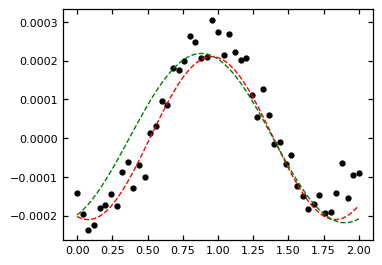

In [24]:
plt.figure(figsize=(4,3))

_, datadict = search_datadict_miyamura(data_path,
                "2025-02-05", acquire_time="175235",name="drag")
time = datadict["beta"]["values"]
s11 = datadict["s11"]["values"]
plt.plot(time, s11.real, "ro--")
# _, datadict = search_datadict_miyamura(data_path,
#                 "2025-02-05", acquire_time="183425",name="drag")
# time = datadict["beta"]["values"]
# s11 = datadict["s11"]["values"]
# plt.plot(time, s11.real, "bo")
_, datadict = search_datadict_miyamura(data_path,
                "2025-02-05", acquire_time="175331",name="drag")
time = datadict["beta"]["values"]
s11 = datadict["s11"]["values"]
plt.plot(time, s11.real, "go--")
plt.show()

a = Analysis(s11, time)
res = a.fit_1d(kind="rabi")
print(res.fit_report())
plt.figure(figsize=(4,3))
plt.plot(time, a.pca(), "ko")
plt.plot(time, res.best_fit, "r--")
plt.plot(time, res.init_fit, "g--")
plt.show()

## ef pi pulse

### rabi

[-0.0031038409362986494, 0.09482985188025335, 0.19276354469680534, 0.29069723751335735, 0.3886309303299093, 0.48656462314646143, 0.5844983159630134, 0.6824320087795654, 0.7803657015961174, 0.8782993944126695, 0.9762330872292214, 1.0741667800457735]
[[Model]]
    Model(sine)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 17
    # data points      = 120
    # variables        = 3
    chi-square         = 1.7588e-06
    reduced chi-square = 1.5032e-08
    Akaike info crit   = -2158.60441
    Bayesian info crit = -2150.24193
    R-squared          = 0.97613005
[[Variables]]
    amplitude:  0.00109226 +/- 1.5794e-05 (1.45%) (init = 0.001065834)
    frequency:  32.0787725 +/- 0.04217222 (0.13%) (init = 31.41593)
    shift:      4.81195639 +/- 0.02897796 (0.60%) (init = 5.140788)
[[Correlations]] (unreported correlations are < 0.100)
    C(frequency, shift) = -0.8652


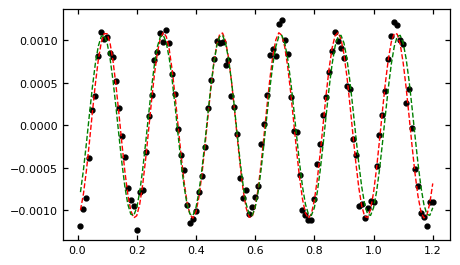

In [25]:
_, datadict = search_datadict_miyamura(data_path, "2025-02-05",
                                        acquire_time="175503",
                                        name="pi_amp")
time = datadict["amplitude"]["values"]
s11 = datadict["s11"]["values"]
a = Analysis(s11, time)
res = a.fit_1d(kind="rabi")
print(res.fit_report())
plt.figure(figsize=(5, 3))

plt.plot(time, a.pca(), "ko")
plt.plot(time, res.best_fit, "r--")
plt.plot(time, res.init_fit, "g--")
plt.show()

### ramsey

[[Model]]
    Model(modelf)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 55
    # data points      = 100
    # variables        = 5
    chi-square         = 3.0723e-08
    reduced chi-square = 3.2340e-10
    Akaike info crit   = -2180.34366
    Bayesian info crit = -2167.31781
    R-squared          = 0.30143209
[[Variables]]
    T2:    6331.22507 +/- 11127.0704 (175.75%) (init = 1411.3)
    freq:  0.00437973 +/- 4.2164e-05 (0.96%) (init = 0.0045)
    A:     1.9058e-05 +/- 5.5738e-06 (29.25%) (init = 5.262198e-05)
    phi:   1.30452820 +/- 0.27936204 (21.41%) (init = 0.6327816)
    off:   4.1995e-07 +/- 1.8035e-06 (429.45%) (init = -1.685172e-20)
[[Correlations]] (unreported correlations are < 0.100)
    C(T2, A)     = -0.8454
    C(freq, phi) = -0.8356


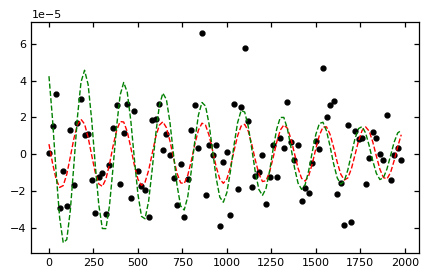

In [13]:
_, datadict = search_datadict_miyamura(data_path, "2025-02-04", 
                                       acquire_time="212612", name="ramsey")
time = datadict["delay"]["values"]
s11 = datadict["s11"]["values"]
a = Analysis(s11, time)
res = a.fit_1d(kind="ramsey")
print(res.fit_report())
plt.figure(figsize=(5, 3))
plt.plot(time, a.pca(), "ko")
plt.plot(time, res.best_fit, "r--")
plt.plot(time, res.init_fit, "g--")
plt.show()

[[Model]]
    Model(modelf)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 54
    # data points      = 100
    # variables        = 5
    chi-square         = 3.1455e-08
    reduced chi-square = 3.3110e-10
    Akaike info crit   = -2177.98898
    Bayesian info crit = -2164.96313
    R-squared          = 0.24005729
[[Variables]]
    T2:    27883.8792 +/- 445064.945 (1596.14%) (init = 2788.389)
    freq:  4.4728e-04 +/- 1.4539e-04 (32.51%) (init = 0.0005)
    A:     1.5138e-05 +/- 5.9220e-06 (39.12%) (init = 5.592152e-05)
    phi:  -0.13049897 +/- 1.05055338 (805.03%) (init = -0.5188131)
    off:   1.3977e-06 +/- 6.3871e-06 (456.97%) (init = 8.605855e-21)
[[Correlations]] (unreported correlations are < 0.100)
    C(freq, phi) = -0.9861
    C(freq, off) = -0.9409
    C(phi, off)  = +0.9301
    C(T2, A)     = -0.8316
    C(T2, off)   = +0.8094
    C(T2, freq)  = -0.7331
    C(T2, phi)   = +0.7118
    C(A, off)    = -0.5014
    C(freq, A)   = +0.4080
    C(A, p

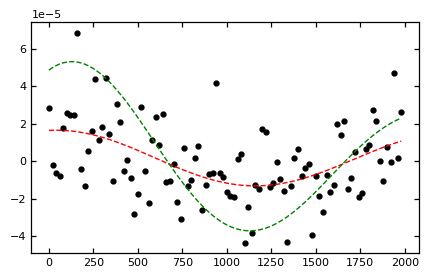

In [14]:
_, datadict = search_datadict_miyamura(data_path, "2025-02-04", 
                                       acquire_time="212708", name="ramsey")
time = datadict["delay"]["values"]
s11 = datadict["s11"]["values"]
a = Analysis(s11, time)
res = a.fit_1d(kind="ramsey")
print(res.fit_report())
plt.figure(figsize=(5, 3))
plt.plot(time, a.pca(), "ko")
plt.plot(time, res.best_fit, "r--")
plt.plot(time, res.init_fit, "g--")
plt.show()

### drag

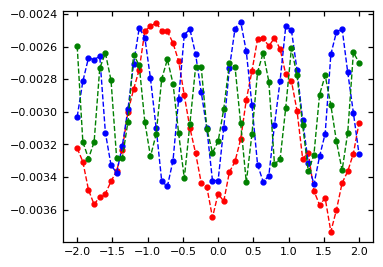

[-2.0599391450566324, -1.83598270824693, -1.6120262714372282, -1.3880698346275258, -1.1641133978178237, -0.9401569610081217, -0.7162005241984197, -0.4922440873887176, -0.2682876505790155, -0.04433121376931341, 0.1796252230403887, 0.40358165985009076, 0.6275380966597929, 0.851494533469495, 1.075450970279197, 1.2994074070888992, 1.523363843898601, 1.7473202807083035]
[[Model]]
    Model(sine)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 17
    # data points      = 51
    # variables        = 3
    chi-square         = 1.9847e-07
    reduced chi-square = 4.1348e-09
    Akaike info crit   = -981.586986
    Bayesian info crit = -975.791509
    R-squared          = 0.97246534
[[Variables]]
    amplitude:  5.2314e-04 +/- 1.2707e-05 (2.43%) (init = 0.0005140966)
    frequency:  14.0276953 +/- 0.02082111 (0.15%) (init = 13.85997)
    shift:      2.19266109 +/- 0.02440640 (1.11%) (init = 2.284795)


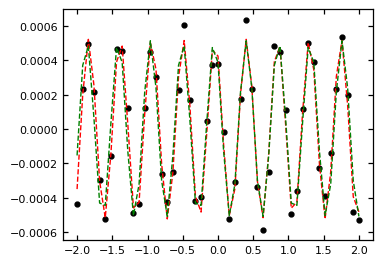

In [28]:
plt.figure(figsize=(4,3))
_, datadict = search_datadict_miyamura(data_path, "2025-02-05", acquire_time="175558", name="drag")
time = datadict["beta"]["values"]
s11 = datadict["s11"]["values"]
plt.plot(time, s11.real, "ro--")
_, datadict = search_datadict_miyamura(data_path, "2025-02-05", acquire_time="175622", name="drag")
time = datadict["beta"]["values"]
s11 = datadict["s11"]["values"]
plt.plot(time, s11.real, "bo--")
_, datadict = search_datadict_miyamura(data_path, "2025-02-05", acquire_time="175714", name="drag")
time = datadict["beta"]["values"]
s11 = datadict["s11"]["values"]
plt.plot(time, s11.real, "go--")
plt.show()

plt.figure(figsize=(4,3))
a = Analysis(s11, time)
res = a.fit_1d(kind="rabi")
print(res.fit_report())
plt.plot(time, a.pca(), "ko")
plt.plot(time, res.best_fit, "r--")
plt.plot(time, res.init_fit, "g--")
plt.show()

### ef half drag

In [ ]:
plt.figure(figsize=(4,3))

_, datadict = search_datadict_miyamura(data_path,
                "2024-08-13", acquire_time="135732",name="drag")
time = datadict["beta"]["values"]
s11 = datadict["s11"]["values"]
plt.plot(time, s11.real, "ro--")
# _, datadict = search_datadict_miyamura(data_path,
#                 "2024-08-13", acquire_time="183425",name="drag")
# time = datadict["beta"]["values"]
# s11 = datadict["s11"]["values"]
# plt.plot(time, s11.real, "bo")
_, datadict = search_datadict_miyamura(data_path,
                "2024-08-13", acquire_time="135829",name="drag")
time = datadict["beta"]["values"]
s11 = datadict["s11"]["values"]
plt.plot(time, s11.real, "go--")
plt.show()

a = Analysis(s11, time)
res = a.fit_1d(kind="rabi")
print(res.fit_report())
plt.figure(figsize=(4,3))
plt.plot(time, a.pca(), "ko")
plt.plot(time, res.best_fit, "r--")
plt.plot(time, res.init_fit, "g--")
plt.show()

## readout pulse optimization

[[Model]]
    Model(s11_ge_dp)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 2459
    # data points      = 2002
    # variables        = 8
    chi-square         = 482.190701
    reduced chi-square = 0.24182081
    Akaike info crit   = -2833.97168
    Bayesian info crit = -2789.15647
    R-squared          = (-1.9563977788803575+2.9630461024459027j)
[[Variables]]
    f_r:    9.35850143 +/- 0.00430938 (0.05%) (init = 9.38111)
    f_f:    9.37041281 +/- 0.01204311 (0.13%) (init = 9.38111)
    k_ex:   0.02034581 +/- 0.01346546 (66.18%) (init = 0.11)
    k_in:   0.01766114 +/- 0.01259107 (71.29%) (init = 0.002)
    chi:   -6.6753e-04 +/- 9.6355e-05 (14.43%) (init = -0.005)
    g:      0.02656361 +/- 0.00144605 (5.44%) (init = 0.05)
    gamma:  7.4785e-04 +/- 0.00151878 (203.09%) (init = 0)
    phi:    0.96979829 +/- 0.34516319 (35.59%) (init = 0)
[[Correlations]] (unreported correlations are < 0.100)
    C(f_r, g)      = -0.9965
    C(k_ex, k_in)  = +0.9879
 

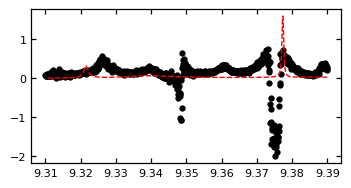

In [ ]:
_, datadict = search_datadict_miyamura(data_path, "2025-02-05", acquire_time="083220", name="spectrum")
probe_frequency = datadict["probe_frequency"]["values"]
s11_g = datadict["s11_g"]["values"]
s11_e = datadict["s11_e"]["values"]
res = probe_resonator_fit_dp(s11_g / s11_e, probe_frequency)
plt.figure(figsize=(4, 2))
plt.plot(probe_frequency, np.unwrap(np.angle(s11_g / s11_e)), "ko")
plt.plot(probe_frequency, np.unwrap(np.angle(res.best_fit)), "r--")
# plt.axvline(10.383,)
print(res.fit_report())
plt.show()

[[Model]]
    Model(s11_ge_dp)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 18000
    # data points      = 202
    # variables        = 8
    chi-square         = 0.05897268
    reduced chi-square = 3.0398e-04
    Akaike info crit   = -1628.06765
    Bayesian info crit = -1601.60151
    R-squared          = -5.8973e+13
##  Warning: uncertainties could not be estimated:
[[Variables]]
    f_r:    10.3799946 (init = 10.38111)
    f_f:    10.0951897 (init = 10.38111)
    k_ex:   0.50007117 (init = 0.11)
    k_in:   6.7363e-08 (init = 0.002)
    chi:   -0.00209760 (init = -0.005)
    g:      0.04959281 (init = 0.05)
    gamma:  0.01010657 (init = 0)
    phi:   -0.33448356 (init = 0)


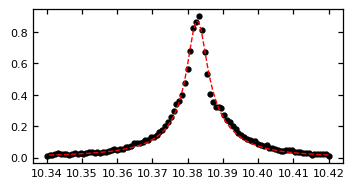

In [32]:
_, datadict = search_datadict_miyamura(data_path, "2025-02-05", acquire_time="175857", name="spectrum")
probe_frequency = datadict["probe_frequency"]["values"]
s11_g = datadict["s11_g"]["values"]
s11_e = datadict["s11_e"]["values"]
res = probe_resonator_fit_dp(s11_g / s11_e, probe_frequency)
plt.figure(figsize=(4, 2))
plt.plot(probe_frequency, np.unwrap(np.angle(s11_g / s11_e)), "ko")
plt.plot(probe_frequency, np.unwrap(np.angle(res.best_fit)), "r--")
# plt.axvline(10.383,)
print(res.fit_report())
plt.show()

In [ ]:
_, datadict = search_datadict_miyamura(data_path, "2024-08-09", acquire_time="112819", name="spectrum")
probe_frequency = datadict["probe_frequency"]["values"]
s11_g = datadict["s11_g"]["values"]
s11_e = datadict["s11_e"]["values"]
res = probe_resonator_fit_dp(s11_g / s11_e, probe_frequency)
plt.figure(figsize=(2, 1))
plt.plot(probe_frequency, np.unwrap(np.angle(s11_g / s11_e)), "ko")
plt.plot(probe_frequency, np.unwrap(np.angle(res.best_fit)), "r--")
plt.axvline(9.383,)
plt.xlabel("Probe frequency (GHz)") ;plt.ylabel(r"$\mathrm{arg}(S_{11}^g/S_{11}^e)$")
print(res.fit_report())
plt.show()

In [ ]:
a = False
-a * 2 + 1

In [ ]:
_, datadict = search_datadict_miyamura(data_path, "2024-08-09", acquire_time="112330", name="spectrum")
probe_frequency = datadict["probe_frequency"]["values"]
s11_g = datadict["s11_g"]["values"]
s11_e = datadict["s11_e"]["values"]
res = probe_resonator_fit_dp(s11_g / s11_e, probe_frequency)
plt.figure(figsize=(2, 1))
plt.plot(probe_frequency, np.unwrap(np.angle(s11_g / s11_e)), "ko")
plt.plot(probe_frequency, np.unwrap(np.angle(res.best_fit)), "r--")
plt.axvline(9.383,)
plt.xlabel("Probe frequency (GHz)") ;plt.ylabel(r"$\mathrm{arg}(S_{11}^g/S_{11}^e)$")
plt.axvline(9.383,)
print(res.fit_report())
plt.show()

## fogi

In [ ]:
_, datadict = search_datadict_miyamura(data_path, "2023-12-26", 
                                       acquire_time="233134",
                                       name="shift")
amplitude = np.unique(datadict["amplitude"]["values"])
fogi_frequency = np.unique(datadict["fogi_frequency"]["values"])
s11 = datadict["s11"]["values"].reshape(len(amplitude), len(fogi_frequency))

whole = Analysis(s11, fogi_frequency, amplitude)
whole.plot(labels=["Drive frequency (GHz)", "Amplitude (V)"], N=1000, show=False)
plt.savefig(image_path + f"{_[:18]}_Stark_shift.jpg", bbox_inches="tight",)

# Single-shot measurement

## JPA squeeze

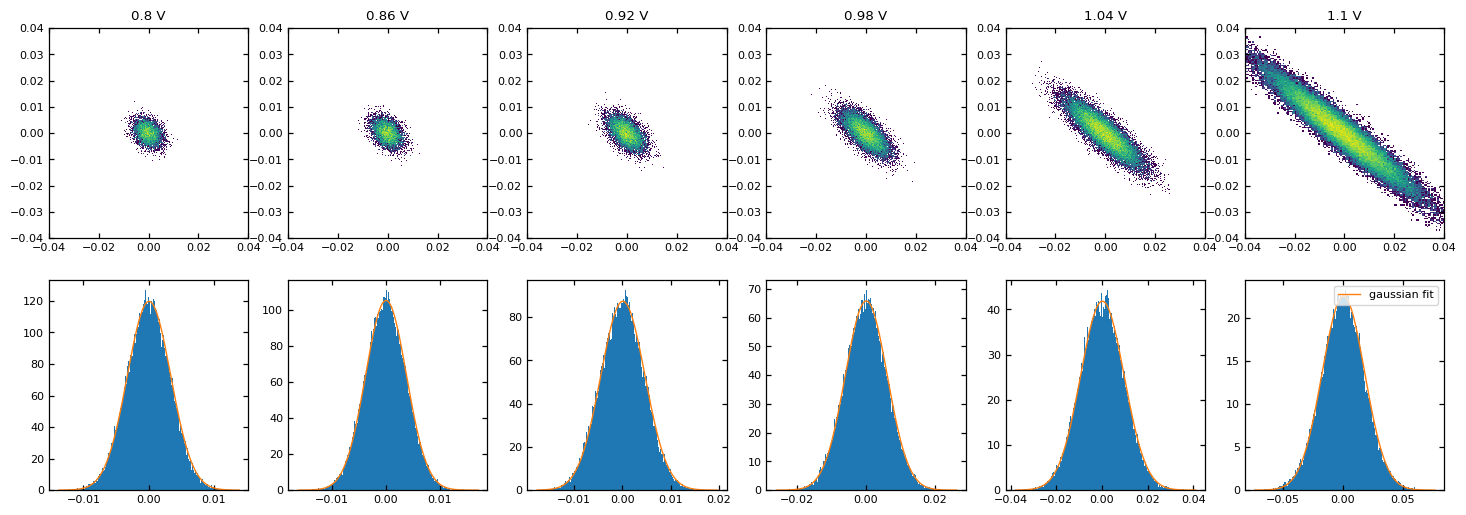

In [44]:
_, datadict = search_datadict_miyamura(data_path, "2025-02-06", acquire_time="130626", name="vac_squeeze")
pump_amplitude = datadict["pump_amplitude"]["values"]
s11 = datadict["s11"]["values"]
fig = plt.figure(figsize=(3 * len(pump_amplitude), 6))
for i in range(len(pump_amplitude)):
    pca = Analysis(s11[i], pump_amplitude[i]).pca()
    hist, bins = np.histogram(pca, bins=200, density=True)
    bins = bins[1:]
    result = gaussian_fit(hist, bins)
    ax = fig.add_subplot(2, len(pump_amplitude), i + 1)
    ax2 = fig.add_subplot(2, len(pump_amplitude), i + 1 + len(pump_amplitude))
    ax.hist2d(s11[i].real, s11[i].imag, bins=200, cmin=1, norm=mcolors.LogNorm())
    ax.set_title(f"{np.round(pump_amplitude[i], decimals=3)} V")
    ax.hist2d(s11[i].real, s11[i].imag, bins=200, cmin=1, norm=mcolors.LogNorm())
    ax.set_xlim(-0.04, 0.04)
    ax.set_ylim(-0.04, 0.04)
    ax2.hist(pca, bins=200, density=True, log=0)
    ax2.plot(bins, result.best_fit, label="gaussian fit")
plt.legend()
plt.show()


In [ ]:
_, datadict = search_datadict_miyamura(data_path, "2024-08-13", acquire_time="155216", name="vac_squeeze")
pump_amplitude = datadict["pump_amplitude"]["values"]
s11 = datadict["s11"]["values"]
fig = plt.figure(figsize=(3 * len(pump_amplitude), 6))
for i in range(len(pump_amplitude)):
    pca = Analysis(s11[i], pump_amplitude[i]).pca()
    hist, bins = np.histogram(pca, bins=200, density=True)
    bins = bins[1:]
    result = gaussian_fit(hist, bins)
    ax = fig.add_subplot(2, len(pump_amplitude), i + 1)
    ax2 = fig.add_subplot(2, len(pump_amplitude), i + 1 + len(pump_amplitude))
    ax.hist2d(s11[i].real, s11[i].imag, bins=200, cmin=1, norm=mcolors.LogNorm())
    ax.set_title(f"{np.round(pump_amplitude[i], decimals=3)} V")
    ax.hist2d(s11[i].real, s11[i].imag, bins=200, cmin=1, norm=mcolors.LogNorm())
    ax.set_xlim(-0.04, 0.04)
    ax.set_ylim(-0.04, 0.04)
    ax2.hist(pca, bins=200, density=True, log=0)
    ax2.plot(bins, result.best_fit, label="gaussian fit")
plt.legend()
plt.show()


In [ ]:
_, datadict = search_datadict_miyamura(data_path, "2024-08-14", acquire_time="005658", name="vac_squeeze")
pump_amplitude = datadict["pump_amplitude"]["values"]
s11 = datadict["s11"]["values"]
fig = plt.figure(figsize=(3 * len(pump_amplitude), 6))
for i in range(len(pump_amplitude)):
    pca = Analysis(s11[i], pump_amplitude[i]).pca()
    hist, bins = np.histogram(pca, bins=200, density=True)
    bins = bins[1:]
    result = gaussian_fit(hist, bins)
    ax = fig.add_subplot(2, len(pump_amplitude), i + 1)
    ax2 = fig.add_subplot(2, len(pump_amplitude), i + 1 + len(pump_amplitude))
    ax.hist2d(s11[i].real, s11[i].imag, bins=200, cmin=1, norm=mcolors.LogNorm())
    ax.set_title(f"{np.round(pump_amplitude[i], decimals=3)} V")
    ax.hist2d(s11[i].real, s11[i].imag, bins=200, cmin=1, norm=mcolors.LogNorm())
    ax.set_xlim(-0.04, 0.04)
    ax.set_ylim(-0.04, 0.04)
    ax2.hist(pca, bins=200, density=True, log=0)
    ax2.plot(bins, result.best_fit, label="gaussian fit")
plt.legend()
plt.show()


In [ ]:
_, datadict = search_datadict_miyamura(data_path, "2024-08-08", acquire_time="184554", name="vac_squeeze")
pump_amplitude = datadict["pump_amplitude"]["values"]
s11 = datadict["s11"]["values"]
fig = plt.figure(figsize=(3 * len(pump_amplitude), 6))
for i in range(len(pump_amplitude)):
    pca = Analysis(s11[i], pump_amplitude[i]).pca()
    hist, bins = np.histogram(pca, bins=200, density=True)
    bins = bins[1:]
    result = gaussian_fit(hist, bins)
    ax = fig.add_subplot(2, len(pump_amplitude), i + 1)
    ax2 = fig.add_subplot(2, len(pump_amplitude), i + 1 + len(pump_amplitude))
    ax.hist2d(s11[i].real, s11[i].imag, bins=200, cmin=1, norm=mcolors.LogNorm())
    ax.set_title(f"{np.round(pump_amplitude[i], decimals=3)} V")
    ax.hist2d(s11[i].real, s11[i].imag, bins=200, cmin=1, norm=mcolors.LogNorm())
    ax.set_xlim(-0.04, 0.04)
    ax.set_ylim(-0.04, 0.04)
    ax2.hist(pca, bins=200, density=True, log=0)
    ax2.plot(bins, result.best_fit, label="gaussian fit")
plt.legend()
plt.show()


In [ ]:
_, datadict = search_datadict_miyamura(data_path, "2024-08-08", acquire_time="190348", name="vac_squeeze")
pump_amplitude = datadict["pump_amplitude"]["values"]
s11 = datadict["s11"]["values"]
fig = plt.figure(figsize=(3 * len(pump_amplitude), 6))
for i in range(len(pump_amplitude)):
    pca = Analysis(s11[i], pump_amplitude[i]).pca()
    hist, bins = np.histogram(pca, bins=200, density=True)
    bins = bins[1:]
    result = gaussian_fit(hist, bins)
    ax = fig.add_subplot(2, len(pump_amplitude), i + 1)
    ax2 = fig.add_subplot(2, len(pump_amplitude), i + 1 + len(pump_amplitude))
    ax.hist2d(s11[i].real, s11[i].imag, bins=200, cmin=1, norm=mcolors.LogNorm())
    ax.set_title(f"{np.round(pump_amplitude[i], decimals=3)} V")
    ax.hist2d(s11[i].real, s11[i].imag, bins=200, cmin=1, norm=mcolors.LogNorm())
    ax.set_xlim(-0.04, 0.04)
    ax.set_ylim(-0.04, 0.04)
    ax2.hist(pca, bins=200, density=True, log=0)
    ax2.plot(bins, result.best_fit, label="gaussian fit")
plt.legend()
plt.show()


In [ ]:
_, datadict = search_datadict_miyamura(data_path, "2024-04-24", acquire_time="233913", name="vac_squeeze")
pump_amplitude = datadict["pump_amplitude"]["values"]
s11 = datadict["s11"]["values"]
fig = plt.figure(figsize=(3 * len(pump_amplitude), 6))
for i in range(len(pump_amplitude)):
    pca = Analysis(s11[i], pump_amplitude[i]).pca()
    hist, bins = np.histogram(pca, bins=200, density=True)
    bins = bins[1:]
    result = gaussian_fit(hist, bins)
    ax = fig.add_subplot(2, len(pump_amplitude), i + 1)
    ax2 = fig.add_subplot(2, len(pump_amplitude), i + 1 + len(pump_amplitude))
    ax.hist2d(s11[i].real, s11[i].imag, bins=200, cmin=1, norm=mcolors.LogNorm())
    ax.set_title(f"{np.round(pump_amplitude[i], decimals=3)} V")
    ax.hist2d(s11[i].real, s11[i].imag, bins=200, cmin=1, norm=mcolors.LogNorm())
    ax.set_xlim(-0.04, 0.04)
    ax.set_ylim(-0.04, 0.04)
    ax2.hist(pca, bins=200, density=True, log=0)
    ax2.plot(bins, result.best_fit, label="gaussian fit")
plt.legend()
plt.show()

## phase optimization
phase = 0.62 * np.pi

In [ ]:
_, datadict = search_datadict_miyamura(data_path, "2023-09-17", acquire_time="174420")
distance = datadict["distance"]["values"]
phase = datadict["phase"]["values"]
plt.plot(phase, np.abs(distance), "ko")
# plt.xlim(0.5, 1.2)
plt.grid(which="both")
print(phase[np.argmax(np.abs(distance))])

## threshold

In [ ]:
_, datadict = search_datadict_miyamura(data_path, "2023-12-26", 
                                       acquire_time="203831", name="threshold")
signal_g = datadict["signal_g"]["values"].ravel()
signal_e = datadict["signal_e"]["values"].ravel()
plt.hist2d(signal_g.real, signal_g.imag, bins=200, cmin=1, norm=mcolors.LogNorm())
plt.hist2d(signal_e.real, signal_e.imag, bins=200, cmin=1, norm=mcolors.LogNorm())
plt.xlim(-0.15, 0.15);plt.ylim(-0.15, 0.15)
plt.show()

In [ ]:
_, datadict = search_datadict_miyamura(data_path, "2023-08-30", 
                                       acquire_time="184351")
s11_g = datadict["s11_g"]["values"].ravel()
s11_e = datadict["s11_e"]["values"].ravel()
s11_f = datadict["s11_e"]["values"].ravel()
signal_g = datadict["signal_g"]["values"].ravel()
signal_e = datadict["signal_e"]["values"].ravel()
signal_f = datadict["signal_e"]["values"].ravel()
plt.figure(figsize=(4, 4))
# plt.hist2d(s11_g.real, s11_g.imag, bins=200, cmin=1, norm=mcolors.LogNorm())
# plt.hist2d(s11_e.real, s11_e.imag, bins=200, cmin=1, norm=mcolors.LogNorm())
# plt.hist2d(s11_f.real, s11_f.imag, bins=200, cmin=1, norm=mcolors.LogNorm())
plt.scatter(s11_g.real, s11_g.imag, alpha=0.5, s=0.1)
plt.scatter(s11_e.real, s11_e.imag, alpha=0.5, s=0.1)
plt.scatter(s11_f.real, s11_f.imag, alpha=0.5, s=0.1)
plt.xlim(-0.06, 0.06)
plt.ylim(-0.06, 0.06)
plt.show()
signal_g = datadict["signal_g"]["values"].ravel()
signal_e = datadict["signal_e"]["values"].ravel()
signal_f = datadict["signal_f"]["values"].ravel()
plt.hist(signal_g, bins=200, alpha=0.5, log=0)
plt.hist(signal_e, bins=200, alpha=0.5, log=0)
plt.hist(signal_f, bins=200, alpha=0.5, log=0)
plt.show()
print(f"g: {1- len([el for el in signal_g if el>0.5])/len(signal_g)}")
print(f"e: {1- len([el for el in signal_e if el>0.5])/len(signal_e)}")
print(f"f: {1- len([el for el in signal_f if el>0.5])/len(signal_f)}")

## QND fidelity

QND fidelity for g: 0.55544
QND fidelity for e: 0.77792


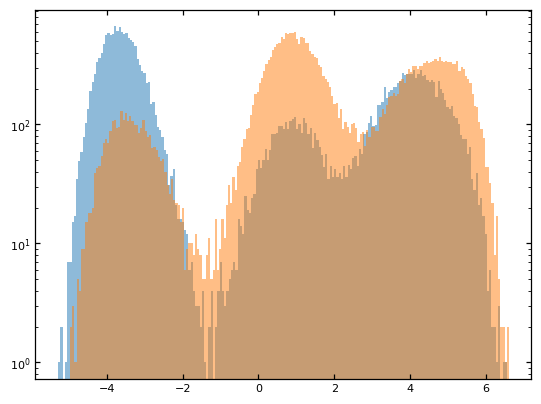

In [49]:
_, datadict = search_datadict_miyamura(data_path, "2025-02-06", 
                                    acquire_time="134112", name="QND")
signal_g = datadict["signal_g"]["values"].ravel()
signal_e = datadict["signal_e"]["values"].ravel()

plt.hist(signal_g, bins=200, alpha=0.5, log=True)
plt.hist(signal_e, bins=200, alpha=0.5, log=True)
print(f"QND fidelity for g: {1- len([el for el in signal_g if el>0.5])/len(signal_g):.5f}")
print(f"QND fidelity for e: {1- len([el for el in signal_e if el<0.5])/len(signal_e):.5f}")

## readout fidelity

readout fidelity for g: 0.96836
readout fidelity for e: 0.88018


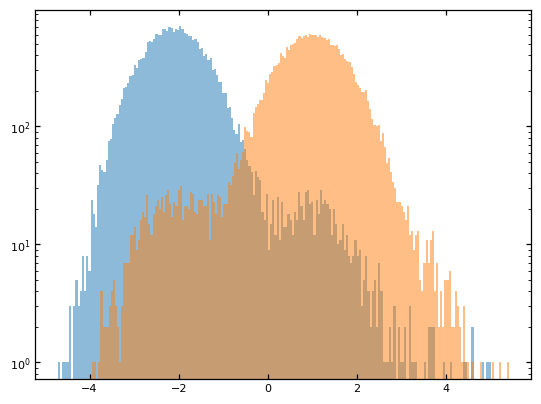

In [52]:
_, datadict = search_datadict_miyamura(data_path, "2025-02-06", 
                                    acquire_time="134342", name="readout")
signal_g = datadict["signal_g"]["values"].ravel()
signal_e = datadict["signal_e"]["values"].ravel()

plt.hist(signal_g, bins=200, alpha=0.5, log=1)
plt.hist(signal_e, bins=200, alpha=0.5)
print(f"readout fidelity for g: {1- len([el for el in signal_g if el>0.5])/len(signal_g):.5f}")
print(f"readout fidelity for e: {1- len([el for el in signal_e if el<0.5])/len(signal_e):.5f}")
# print(dataset.metadata["setup_script_JPA"])

In [ ]:
if measure_which == "rx":
    seq = Sequence(port_list=ports_rx)
    seq.call(ge_pi_seq_rx)
    seq.add(SetDetuning(Appeared_anhm), qubit_drive_port_rx)
    seq.trigger([qubit_drive_port_rx, fogi_port_rx])
    seq.add(FlatTop(Gaussian(amplitude=fogi_amplitude, fwhm=12, duration=40), top_duration=1000), fogi_port_rx)
    seq.add(FlatTop(Gaussian(amplitude=amplitude, fwhm=12, duration=40), top_duration=1000), qubit_drive_port_rx)
    seq.trigger(ports_rx)
    seq.call(readout_ss_seq_rx)

In [ ]:
_, datadict = search_datadict_miyamura(data_path, "2024-08-10", 
                                    acquire_time="184257", name="readout")
signal_g = datadict["signal_g"]["values"].ravel()
signal_e = datadict["signal_e"]["values"].ravel()

plt.hist(signal_g, bins=200, alpha=0.5, log=1)
plt.hist(signal_e, bins=200, alpha=0.5)
print(f"readout fidelity for g: {1- len([el for el in signal_g if el>0.5])/len(signal_g):.5f}")
print(f"readout fidelity for e: {1- len([el for el in signal_e if el<0.5])/len(signal_e):.5f}")
# print(dataset.metadata["setup_script_JPA"])

In [ ]:
_, datadict = search_datadict_miyamura(data_path, "2024-08-09", 
                                    acquire_time="164306", name="readout")
signal_g = datadict["signal_g"]["values"].ravel()
signal_e = datadict["signal_e"]["values"].ravel()

plt.hist(signal_g, bins=200, alpha=0.5, log=1)
plt.hist(signal_e, bins=200, alpha=0.5)
print(f"readout fidelity for g: {1- len([el for el in signal_g if el>0.5])/len(signal_g):.5f}")
print(f"readout fidelity for e: {1- len([el for el in signal_e if el<0.5])/len(signal_e):.5f}")
# print(dataset.metadata["setup_script_JPA"])

## thermal population

In [ ]:
_, datadict = search_datadict_miyamura(data_path, "2024-08-10",
                                    acquire_time="170119", name="population")
signal = datadict["signal"]["values"].ravel()

plt.figure(figsize=(3, 2))
plt.hist(signal, bins=200, alpha=0.5, log=0)
plt.axvline(0.5)
print(f"g population: {1- len([el for el in signal if el>0.5])/len(signal)}")

from scipy.constants import h, k
print(f"effective temp. {-h*7.690920e9/k/np.log(len([el for el in signal if el>0.5])/len(signal))}")

In [ ]:
from scipy.constants import h, k
import numpy as np
print(f"effective temp. {-h*8.2e9/k/np.log(1-0.994)}")

In [ ]:
_, datadict = search_datadict_miyamura(data_path, "2024-08-10",
                                    acquire_time="170209", name="population")
signal = datadict["signal"]["values"].ravel()

plt.figure(figsize=(3, 2))
plt.hist(signal, bins=200, alpha=0.5, log=0)
plt.axvline(0.5)
print(f"g population: {1- len([el for el in signal if el>0.5])/len(signal)}")

from scipy.constants import h, k
print(f"effective temp. {-h*7.690920e9/k/np.log(len([el for el in signal if el>0.5])/len(signal))}")

In [ ]:
_, datadict = search_datadict_miyamura(data_path, "2024-08-11",
                                    acquire_time="153829", name="reset")
signal = datadict["signal"]["values"].ravel()

plt.figure(figsize=(4, 2))
plt.hist(signal, bins=200, alpha=0.5, log=0)
print(f"g population: {1- len([el for el in signal if el>0.5])/len(signal)}")

from scipy.constants import h, k
print(f"effective temp. {-h*7.7e9/k/np.log(len([el for el in signal if el>0.5])/len(signal))}")

In [ ]:
_, datadict = search_datadict_miyamura(data_path, "2024-08-11",
                                    acquire_time="153740", name="reset")
signal = datadict["signal"]["values"].ravel()

plt.figure(figsize=(4, 2))
plt.hist(signal, bins=200, alpha=0.5, log=0)
print(f"g population: {1- len([el for el in signal if el>0.5])/len(signal)}")

from scipy.constants import h, k
print(f"effective temp. {-h*7.7e9/k/np.log(len([el for el in signal if el>0.5])/len(signal))}")

## probe resonator with post-selection

In [ ]:
_, datadict = search_datadict_miyamura(data_path, "2024-07-27",
                                    acquire_time="193457", name="selec")
s11_g = datadict["s11_g"]["values"].ravel()
s11_e = datadict["s11_e"]["values"].ravel()
probe_frequency = datadict["probe_frequency"]["values"].ravel()
ratio_ge = (s11_g/s11_e)
result = probe_resonator_fit_dp(ratio_ge, probe_frequency)
print(result.fit_report())
plt.figure(figsize=(3,3))
plt.plot(probe_frequency, np.unwrap(np.angle(ratio_ge)), "ko")
plt.plot(probe_frequency, np.unwrap(np.angle(result.best_fit)), "r-")
plt.plot(probe_frequency, np.unwrap(np.angle(result.init_fit)), "g-")
plt.ylabel("phase (rad)")
plt.xlabel("probe frequency (GHz)")
# plt.savefig(image_path+f'{dataset.run_id}_probe_resonator_phase.jpg',bbox_inches="tight",)
# plt.plot(probe_freq, np.unwrap(np.angle(s11g)))
# plt.plot(probe_freq, np.unwrap(np.angle(s11e)))
plt.show()
plt.figure(figsize=(3,3))
plt.plot(probe_frequency, np.abs(ratio_ge), "ko")
plt.plot(probe_frequency, np.abs(result.best_fit), "r-")
plt.plot(probe_frequency, np.abs(result.init_fit), "g-")
# plt.ylim(0,1.1)
plt.ylabel("$|S_{11,g}/S_{11,e}|$ (a.u.)")
plt.xlabel("probe frequency (GHz)")
# plt.savefig(image_path+f'{dataset.run_id}_probe_resonator_mag.jpg',bbox_inches="tight",)
plt.show()
plt.figure(figsize=(3,3))
plt.plot(ratio_ge.real, ratio_ge.imag, 'ko')
plt.plot(result.best_fit.real, result.best_fit.imag, 'r-')
plt.ylabel("Re[$|S_{11,g}/S_{11,e}|$] (a.u.)");plt.ylim(-0, 1.1)
plt.xlabel("Im[$|S_{11,g}/S_{11,e}|$] (a.u.)");plt.xlim(-0, 1.1)
# plt.savefig(image_path+f'{dataset.run_id}_probe_resonator_iq.jpg',bbox_inches="tight",)

In [ ]:
_, datadict = search_datadict_miyamura(data_path, "2024-07-29",
                                    acquire_time="154323", name="selec")
s11_g = datadict["s11_g"]["values"].ravel()
s11_e = datadict["s11_e"]["values"].ravel()
probe_frequency = datadict["probe_frequency"]["values"].ravel()
ratio_ge = (s11_g/s11_e)
result = probe_resonator_fit_dp(ratio_ge, probe_frequency)
print(result.fit_report())
plt.figure(figsize=(3,3))
plt.plot(probe_frequency, np.unwrap(np.angle(ratio_ge)), "ko")
plt.plot(probe_frequency, np.unwrap(np.angle(result.best_fit)), "r-")
plt.plot(probe_frequency, np.unwrap(np.angle(result.init_fit)), "g-")
plt.ylabel("phase (rad)")
plt.xlabel("probe frequency (GHz)")
# plt.savefig(image_path+f'{dataset.run_id}_probe_resonator_phase.jpg',bbox_inches="tight",)
# plt.plot(probe_freq, np.unwrap(np.angle(s11g)))
# plt.plot(probe_freq, np.unwrap(np.angle(s11e)))
plt.show()
plt.figure(figsize=(3,3))
plt.plot(probe_frequency, np.abs(ratio_ge), "ko")
plt.plot(probe_frequency, np.abs(result.best_fit), "r-")
plt.plot(probe_frequency, np.abs(result.init_fit), "g-")
# plt.ylim(0,1.1)
plt.ylabel("$|S_{11,g}/S_{11,e}|$ (a.u.)")
plt.xlabel("probe frequency (GHz)")
# plt.savefig(image_path+f'{dataset.run_id}_probe_resonator_mag.jpg',bbox_inches="tight",)
plt.show()
plt.figure(figsize=(3,3))
plt.plot(ratio_ge.real, ratio_ge.imag, 'ko')
plt.plot(result.best_fit.real, result.best_fit.imag, 'r-')
plt.ylabel("Re[$|S_{11,g}/S_{11,e}|$] (a.u.)");plt.ylim(-0, 1.1)
plt.xlabel("Im[$|S_{11,g}/S_{11,e}|$] (a.u.)");plt.xlim(-0, 1.1)
# plt.savefig(image_path+f'{dataset.run_id}_probe_resonator_iq.jpg',bbox_inches="tight",)

# Coherences

In [ ]:
# results = list(search_datadicts("D:\\miyamura\\result\\coherence", "2024-08-11", until="2024-08-12", name="rx_TD_t1ge"))
results = list(search_datadicts("D:\\miyamura\\result\\coherence", "2024-08-13", until="2024-08-13", name="tx_TD_t1ge"))
T1 = []
errs = []
time_performed=[]
for result in results:
    _, datadict = result
    delay = datadict["delay"]["values"]
    s11 = datadict["s11"]["values"]
    a = Analysis(s11, delay)
    res = a.fit_1d(kind="decay")
    if res.result.params['T1'].stderr is None :continue
    if res.result.params['T1'].stderr > 10000 :continue
    T1.append(res.params.valuesdict()['T1'])
    errs.append(res.result.params['T1'].stderr)
    time_performed.append(_[0:17])
plt.figure(figsize=(20, 6))
plt.errorbar(time_performed, T1, yerr=errs, capsize=5, fmt='o')
plt.xticks(rotation=90)
# plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(integer=True)
plt.ylabel("T1 ge (us)");plt.xlabel("Datetime")
plt.savefig(image_path + f"t1ge_{time_performed[0][0:10]}_{time_performed[-1][0:10]}.jpg", bbox_inches="tight",)
plt.show()
print(f"{np.mean(T1):.0f} +- {np.std(T1):.0f}")

In [ ]:
_, datadict = search_datadict_miyamura("D:\\miyamura\\result\\coherence", 
                                       "2024-08-08", acquire_time="170934",
                                       name="t1ge")
delay = datadict["delay"]["values"]
s11 = datadict["s11"]["values"]
a = Analysis(s11, delay)
res = a.fit_1d(kind="decay")
plt.figure(figsize=(4, 2))
plt.plot(delay, a.pca(), "ko")
plt.plot(delay, res.best_fit, "r--")
plt.plot(delay, res.init_fit, "g--")
plt.xlabel("Time (ns)")
print(np.mean(a.pca()[-5:]))
print(res.fit_report())

In [ ]:
_, datadict = search_datadict_miyamura("D:\\miyamura\\result\\coherence", 
                                       "2024-08-08", acquire_time="193200",
                                       name="t1ge")
delay = datadict["delay"]["values"]
s11 = datadict["s11"]["values"]
a = Analysis(s11, delay)
res = a.fit_1d(kind="decay")
plt.figure(figsize=(4, 2))
plt.plot(delay, a.pca(), "ko")
plt.plot(delay, res.best_fit, "r--")
plt.plot(delay, res.init_fit, "g--")
plt.xlabel("Time (ns)")
print(np.mean(a.pca()[-5:]))
print(res.fit_report())

In [ ]:
# results = list(search_datadicts("D:\\miyamura\\result\\coherence", "2024-08-11", until="2024-08-11", name="rx_TD_t1ef"))
results = list(search_datadicts("D:\\miyamura\\result\\coherence", "2024-08-13", until="2024-08-13", name="tx_TD_t1ef"))
T1 = []
errs = []
time_performed=[]
for result in results:
    _, datadict = result
    delay = datadict["delay"]["values"]
    s11 = datadict["s11"]["values"]
    a = Analysis(s11, delay)
    res = a.fit_1d(kind="decay")
    if res.result.params['T1'].stderr is None :continue
    if res.result.params['T1'].stderr > 10000 :continue
    T1.append(res.params.valuesdict()['T1'])
    errs.append(res.result.params['T1'].stderr)
    time_performed.append(_[0:17])
plt.figure(figsize=(20, 6))
plt.errorbar(time_performed, T1, yerr=[e if e is not None else 0 for e in errs], capsize=5, fmt='o')
plt.xticks(rotation=90)
# plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(integer=True)
plt.ylabel("T1 ef (us)") ;plt.xlabel("Datetime")
plt.savefig(image_path + f"t1ef_{time_performed[0][0:10]}_{time_performed[-1][0:10]}.jpg", bbox_inches="tight",)
print(f"{np.mean(T1):.0f} +- {np.std(T1):.0f}")
plt.show()

In [ ]:
_, datadict = search_datadict_miyamura("D:\\miyamura\\result\\coherence", 
                                       "2024-08-08", acquire_time="171033",
                                       name="t1ef")
delay = datadict["delay"]["values"]
s11 = datadict["s11"]["values"]
a = Analysis(s11, delay)
res = a.fit_1d(kind="decay")
plt.figure(figsize=(4, 2))
plt.plot(delay, a.pca(), "ko")
plt.plot(delay, res.best_fit, "r--")
plt.plot(delay, res.init_fit, "g--")
print(np.mean(a.pca()[-5:]))
print(res.fit_report())

In [ ]:
_, datadict = search_datadict_miyamura("D:\\miyamura\\result\\coherence", 
                                       "2024-08-08", acquire_time="193300",
                                       name="t1ef")
delay = datadict["delay"]["values"]
s11 = datadict["s11"]["values"]
a = Analysis(s11, delay)
res = a.fit_1d(kind="decay")
plt.figure(figsize=(4, 2))
plt.plot(delay, a.pca(), "ko")
plt.plot(delay, res.best_fit, "r--")
plt.plot(delay, res.init_fit, "g--")
print(np.mean(a.pca()[-5:]))
print(res.fit_report())

In [ ]:
# results = list(search_datadicts("D:\\miyamura\\result\\coherence",  "2024-08-11", until="2024-08-11", name="x_TD_t2ge_echo"))
results = list(search_datadicts("D:\\miyamura\\result\\coherence",  "2024-08-13", until="2024-08-13", name="tx_TD_t2ge_echo"))
T1 = []
errs = []
time_performed=[]
for result in results:
    _, datadict = result
    delay = datadict["delay"]["values"]
    s11 = datadict["s11"]["values"]
    a = Analysis(s11, delay)
    res = a.fit_1d(kind="decay")
    T1.append(res.params.valuesdict()['T1'])
    errs.append(res.result.params['T1'].stderr)
    time_performed.append(_[0:17])
plt.figure(figsize=(20, 6))
plt.errorbar(time_performed, T1, yerr=[e if e is not None else 0 for e in errs  ], capsize=5, fmt='o')
plt.xticks(rotation=90)
# plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(integer=True)
plt.ylabel("T2ge echo (us)") ;plt.xlabel("Datetime")
plt.savefig(image_path + f"t2echo_{time_performed[0][0:10]}_{time_performed[-1][0:10]}.jpg", bbox_inches="tight",)
plt.show()
print(f"{np.mean(T1):.0f} +- {np.std(T1):.0f}")

In [ ]:
_, datadict = search_datadict_miyamura("D:\\miyamura\\result\\coherence", 
                                       "2024-08-08", acquire_time="171105",
                                       name="echo")
delay = datadict["delay"]["values"]
s11 = datadict["s11"]["values"]
a = Analysis(s11, delay)
res = a.fit_1d(kind="decay")
plt.figure(figsize=(4, 2))
plt.plot(delay, a.pca(), "ko")
plt.plot(delay, res.best_fit, "r--")
plt.plot(delay, res.init_fit, "g--")
print(np.mean(a.pca()[-5:]))
print(res.fit_report())

In [ ]:
_, datadict = search_datadict_miyamura("D:\\miyamura\\result\\coherence", 
                                       "2024-08-08", acquire_time="193320",
                                       name="echo")
delay = datadict["delay"]["values"]
s11 = datadict["s11"]["values"]
a = Analysis(s11, delay)
res = a.fit_1d(kind="decay")
plt.figure(figsize=(4, 2))
plt.plot(delay, a.pca(), "ko")
plt.plot(delay, res.best_fit, "r--")
plt.plot(delay, res.init_fit, "g--")
print(np.mean(a.pca()[-5:]))
print(res.fit_report())

In [ ]:
# results = list(search_datadicts("D:\\miyamura\\result\\coherence",  "2024-08-11", until="2024-08-11", name="rx_TD_t2ramsey"))
results = list(search_datadicts("D:\\miyamura\\result\\coherence",  "2024-08-13", until="2024-08-13", name="tx_TD_t2ramsey"))
T1 = []
errs = []
time_performed=[]
for result in results:
    _, datadict = result
    delay = datadict["delay"]["values"]
    s11 = datadict["s11"]["values"]
    a = Analysis(s11, delay)
    res = a.fit_1d(kind="ramsey")
    T1.append(res.params.valuesdict()['T2'])
    errs.append(res.result.params['T2'].stderr)
    time_performed.append(_[0:17])
plt.figure(figsize=(20, 6))
plt.errorbar(time_performed, T1, yerr=[e if e is not None and e < 0.1e9 else 0 for e in errs  ], capsize=5, fmt='o')
plt.xticks(rotation=90)
# plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(integer=True)
plt.ylabel("T2ge ramsey (us)");plt.xlabel("Datetime")
plt.savefig(image_path + f"t2ramsey_{time_performed[0][0:10]}_{time_performed[-1][0:10]}.jpg", bbox_inches="tight",)
print(f"{np.mean(T1):.0f} +- {np.std(T1):.0f}")

plt.show()

In [ ]:
_, datadict = search_datadict_miyamura("D:\\miyamura\\result\\coherence", 
                                       "2024-08-08", acquire_time="171146",
                                       name="ramsey")
delay = datadict["delay"]["values"]
s11 = datadict["s11"]["values"]
a = Analysis(s11, delay)
res = a.fit_1d(kind="ramsey")
plt.figure(figsize=(4, 2))
plt.plot(delay, a.pca(), "ko")
plt.plot(delay, res.best_fit, "r--")
plt.plot(delay, res.init_fit, "g--")
print(np.mean(a.pca()[-5:]))
print(res.fit_report())

In [ ]:
_, datadict = search_datadict_miyamura("D:\\miyamura\\result\\coherence", 
                                       "2024-08-08", acquire_time="193350",
                                       name="ramsey")
delay = datadict["delay"]["values"]
s11 = datadict["s11"]["values"]
a = Analysis(s11, delay)
res = a.fit_1d(kind="ramsey")
plt.figure(figsize=(4, 2))
plt.plot(delay, a.pca(), "ko")
plt.plot(delay, res.best_fit, "r--")
plt.plot(delay, res.init_fit, "g--")
print(np.mean(a.pca()[-5:]))
print(res.fit_report())

# Test

In [ ]:
_, datadict = search_datadict_miyamura(data_path, "2024-04-23", acquire_time="152322", name="spectrum")
frequency = np.unique(datadict["frequency"]["values"]) / 1e9
s11 = datadict["s11"]["values"]

_, datadict = search_datadict_miyamura(data_path, "2024-04-27",
                                    acquire_time="100058", name="selec")
s11_g = datadict["s11_g"]["values"].ravel()
s11_e = datadict["s11_e"]["values"].ravel()
probe_frequency = datadict["probe_frequency"]["values"].ravel()
ratio_ge = (s11_g/s11_e)

def s11_two2(f, fr, ff, ke, ki, g, gamma, alpha, Ed, A, phi):
    # top = 1j * (f - ff) - (ki-ke)/2 + g**2 / (1j*(f-fr)-gamma/2)
    # bottom =  1j * (f - ff) - (ki+ke)/2 + g**2 / (1j*(f-fr)-gamma/2)
    # ideal = np.conj(top / bottom)
    ideal = np.conj(np.cos(phi) + np.exp(1j*phi) * ke * (1j*(f-fr) - gamma/2)/((1j*(f-ff)-(ke+ki)/2) * (1j*(f-fr)-gamma/2) + g**2))
    env = A*np.exp(1j*(alpha - 2*np.pi*(f-fr)*Ed))
    return ideal * env

def combined(fs, fr, ff, ke, ki, g, gamma, alpha, Ed, A, chi, phi):
    f1 = fs[:len(frequency)] ;f2 = fs[len(frequency):]
    data1 = s11_two2(f1, fr, ff, ke, ki, g, gamma, alpha, Ed, A, phi)
    data2 = s11_ge_dp(f2, fr, ff, ke, ki, chi, g, gamma, phi)
    return np.append(data1, data2)
def guess_params_combined():
    par_ini = {"fr":10.2663654, "ff":10.173, "ke":0.18, "ki":0, "g": 0.082, "gamma":0, "alpha":2.12588100, "Ed":-0.42608, "A": 0.0028, "chi":-5e-3, "phi":0,}
    par_max = {"fr":12, "ff":12, "ke":0.5, "ki":100e-3, "g":800e-3, "gamma":0.01, "alpha":np.pi, "Ed":100, "A":0.5, "chi":0, "phi":2 * np.pi}
    par_min = {"fr":0, "ff":0, "ke":0, "ki":0, "g":0, "gamma":0, "alpha":-np.pi, "Ed":-100, "A":0, "chi":-50e-3, "phi":-2*np.pi,}
    par_vary = {"fr":False, "ff":False, "ke":True, "ki":0, "g":True, "gamma":0, "alpha":1, "Ed":1, "A":True, "chi":1, "phi":1}
    return par_ini,par_max,par_min,par_vary
def combined_fit(data, x):
    import lmfit as lmf
    model = lmf.Model(combined)
    params = model.make_params()
    par_ini,par_max,par_min,par_vary=guess_params_combined()
    for name in params:
        params[name].set(
            value=par_ini[name],  # 初期値
            min=par_min[name],  # 下限値
            max=par_max[name],  # 上限値
            vary=par_vary[name] # パラメータを動かすかどうか
        )
    result=model.fit(data, fs=x, params=params, method='leastsq')
    return result

result = combined_fit(np.append(s11, ratio_ge), np.append(frequency, probe_frequency))
print(result.fit_report())

plt.plot(s11.real, s11.imag, "ko")
plt.plot(result.best_fit[:len(frequency)].real, result.best_fit[:len(frequency)].imag, "r--")
plt.plot(result.init_fit[:len(frequency)].real, result.init_fit[:len(frequency)].imag, "g--")
plt.show()
plt.plot(frequency, np.angle(s11), "ko")
plt.plot(frequency, np.angle(result.best_fit[:len(frequency)]), "r--")
plt.plot(frequency, np.angle(result.init_fit[:len(frequency)]), "g--")
plt.show()

plt.figure(figsize=(3,3))
plt.plot(probe_frequency, np.unwrap(np.angle(ratio_ge)), "ko")
plt.plot(probe_frequency, np.unwrap(np.angle(result.best_fit[len(frequency):])), "r-")
plt.plot(probe_frequency, np.unwrap(np.angle(result.init_fit[len(frequency):])), "g-")
plt.ylabel("phase (rad)")
plt.xlabel("probe frequency (GHz)")
# plt.savefig(image_path+f'{dataset.run_id}_probe_resonator_phase.jpg',bbox_inches="tight",)
# plt.plot(probe_freq, np.unwrap(np.angle(s11g)))
# plt.plot(probe_freq, np.unwrap(np.angle(s11e)))
plt.show()
plt.figure(figsize=(3,3))
plt.plot(probe_frequency, np.abs(ratio_ge), "ko")
plt.plot(probe_frequency, np.abs(result.best_fit[len(frequency):]), "r-")
plt.plot(probe_frequency, np.abs(result.init_fit[len(frequency):]), "g-")
# plt.ylim(0,1.1)
plt.ylabel("$|S_{11,g}/S_{11,e}|$ (a.u.)")
plt.xlabel("probe frequency (GHz)")
# plt.savefig(image_path+f'{dataset.run_id}_probe_resonator_mag.jpg',bbox_inches="tight",)
plt.show()
plt.figure(figsize=(3,3))
plt.plot(ratio_ge.real, ratio_ge.imag, 'ko')
plt.plot(result.best_fit[len(frequency):].real, result.best_fit[len(frequency):].imag, 'r-')
plt.ylabel("Re[$|S_{11,g}/S_{11,e}|$] (a.u.)")#;plt.ylim(-0, 1.1)
plt.xlabel("Im[$|S_{11,g}/S_{11,e}|$] (a.u.)")#;plt.xlim(-0, 1.1)

# ramsey stark shift

In [ ]:
_, datadict = search_datadict_miyamura(data_path, "2024-04-27", acquire_time="152146", name="shift")
delay = np.unique(datadict["delay"]["values"])
drive_frequency = np.unique(datadict["drive_frequency"]["values"])
drive_power = np.unique(datadict["drive_power"]["values"])
s11 = datadict["s11"]["values"].reshape(len(drive_frequency), len(drive_power), len(delay))
# print(datadict["drive_power"]["values"].reshape(len(drive_frequency), len(drive_power), len(delay)))
# print(datadict["drive_frequency"]["values"].reshape(len(drive_frequency), len(drive_power), len(delay)))
# print(datadict["delay"]["values"].reshape(len(drive_frequency), len(drive_power), len(delay)))
# raise SystemError


from scipy.constants import h
def shift_per_power(f, fr, ff, J, kappa, chi, alpha, gamma):
    g=J
    s11 = np.sqrt(kappa) * J/((1j*(f-ff)-kappa/2) * (1j*(f-fr)-gamma/2) + g**2)
    return alpha * chi * np.abs(s11)**2 / h / f # Hz / Watt
def shift_per_power_fit(data, x):
    import lmfit as lmf
    model = lmf.Model(shift_per_power)
    params = model.make_params()
    par_ini = {"fr":10.3e9, "ff":10.3e9, "kappa":0.20255e9, "chi":-5.18e6, "J":0.08182e9, "gamma":0, "alpha":-3.5827e-39,}
    par_max = {"fr":11e9, "ff":11e9, "kappa":2e9, "chi":0, "J":1e9, "gamma":.3e9, "alpha":np.inf}
    par_min = {"fr":10e9, "ff":10e9, "kappa":0, "chi":-50e6, "J":0, "gamma":0, "alpha":-np.inf,}
    par_vary = {"fr":1, "ff":1, "kappa":1, "chi":False, "J":1, "gamma":0, "alpha":1}
    for name in params:
        params[name].set(
            value=par_ini[name],  # 初期値
            min=par_min[name],  # 下限値
            max=par_max[name],  # 上限値
            vary=par_vary[name] # パラメータを動かすかどうか
        )
    result=model.fit(data, f=x, params=params, method='leastsq')
    return result

print(s11.shape)
# fig = plt.figure(figsize=(2 * len(vna_power), 2 * len(drive_power)))
result = []
for i, vna_f in enumerate(drive_power):
    # Analysis(s11[:, i, :].real, delay, drive_frequency).plot()
    S11 = s11[:, i, :]
    res_i = []
    for j, df in enumerate(drive_frequency):
        # ax = fig.add_subplot(len(vna_power), len(drive_power), i+j*len(drive_power)+1)
        
        tempS11 = Analysis(S11[j], delay).pca()
        res = Fit(tempS11, delay).ramsey_fit()
        # plt.plot(delay, res.best_fit)
        # plt.plot(delay, tempS11)
        # plt.show()

        # ax.plot(frequency, S11)
        # ax.plot(frequency, res.best_fit)
        res_i.append(res.params.valuesdict()["freq"])
    result.append(res_i)
result = np.array(result) / 1e9
# plt.plot(drive_frequency, np.array(result)[4, :])

res = [] ;err=[]
idx_omit = []
for i in range(result.shape[-1]):
    resu = Fit(result[:, i], dBm_Watt(drive_power)).linear_fit()
    res.append(resu.params.valuesdict()["slope"])
    err.append(resu.result.params["slope"].stderr)
    if err[-1] / res[-1] > 0.1:
        idx_omit.append(i) 
        continue
    # plt.plot(dBm_Watt(drive_power), result[:, i])
    # plt.plot(dBm_Watt(drive_power), resu.best_fit)
    # plt.show()
drive_frequency= np.delete(drive_frequency, idx_omit)
res= np.delete(res, idx_omit)
err= np.delete(err, idx_omit)
plt.errorbar(drive_frequency, res, yerr=err)
# plt.subplots_adjust()

fit = shift_per_power_fit(res, drive_frequency)
plt.plot(drive_frequency, fit.best_fit)
print(fit.fit_report())

In [ ]:
plt.errorbar(drive_frequency, res, yerr=err)
# plt.subplots_adjust()

fit = shift_per_power_fit(res, drive_frequency)
plt.plot(drive_frequency, fit.best_fit)
# plt.plot(drive_frequency, fit.init_fit)
print(fit.fit_report())

In [ ]:
_, datadict = search_datadict_miyamura(data_path, "2024-07-29", acquire_time="191014", name="ed")
delay = np.unique(datadict["delay"]["values"])
s11 = datadict["s11"]["values"]
a = Analysis(s11.conj(), delay)
f = Fit(-a.pca(), delay)
r = f.lorentz_fit()
plt.plot(delay, -a.pca(), "ko")
plt.plot(delay, r.best_fit)
r

# communication exp

In [25]:
from tomo.libys import qtp as ysq
from tomo.state_tomography import *
from tomo.process_tomography import *
from qutip import fidelity, Qobj
from mpl_toolkits.mplot3d import Axes3D
from programs.Analysis import polynomial_fit

from scipy.optimize import minimize
def rotation_ge(theta:float, rho):
    R = np.array([
        [1, 0, 0],
        [0, np.exp(1j*theta), 0],
        [0, 0, 1]
    ])
    return R.T.conj() @ rho @ R

def rotation_ef(phi, rho):
    R = np.array([
        [1, 0, 0],
        [0,1,0],
        [0, 0,np.exp(1j*phi)]
    ])
    return R.T.conj() @ rho @ R

def rotation(theta, phi, rho):
    return rotation_ef(phi, rotation_ge(theta, rho))

def optimal_angles(rhos, ideal_rhos):
    def ng_fid(angles):
        theta, phi = angles
        f = 0
        for rho, ideal_rho in zip(rhos, ideal_rhos):
            rot_rho = rotation(theta, phi, rho)
            f -= fidelity(Qobj(rot_rho), Qobj(ideal_rho))
        return f
    result = minimize(ng_fid, (0, 0))
    return result.x

from programs.Analysis import (
    lowpass
)
readout_lo_freq = 9.47
def extract_env(time, waveform, target_freq):
    signal = 2 * lowpass(time, 
                waveform * np.exp(2j*np.pi*(readout_lo_freq-target_freq)*time),
                0.01, 0.05, 0.1, 90)
    return np.abs(signal)
def mode_func(time, waveform, target_freq):
    signal = 2 * lowpass(time, 
                waveform * np.exp(2j*np.pi*(readout_lo_freq-target_freq)*time),
                0.01, 0.05, 0.1, 90)
    return np.abs(signal)
def overlap(wave1, wave2, time):
    norm1=np.sqrt(np.sum(np.abs(wave1)**2) * (time[1]-time[0]))
    norm2 = np.sqrt(np.sum(np.abs(wave2)**2) * (time[1]-time[0]))
    m1_t = wave1 / norm1
    m2_t = wave2 / norm2
    m_2t_star_rev = np.flip(m2_t).conj() 
    m=0
    for i in range(len(wave1)):
        m_t_star_rev_i = np.roll(m_2t_star_rev, i)
        mult = m1_t * m_t_star_rev_i
        mult_sum=np.sum(mult) * (time[1] - time[0])
        cand = np.abs(mult_sum)**2
        if m<cand:
            m=cand
    return m

def show_tomography_result(name_dict:dict):
    rhos = []
    ideal_rhos = []
    for k, v in name_dict.items():
        _, datadict = search_datadict_miyamura(data_path, v["date"], acquire_time=v["acquire_time"], name="all")
        drive_power = (datadict["signal"]["values"])
        meas_prob = []
        for _ in drive_power:
            l = [i for i in _ if i<np.inf]
            meas_prob.append(len([x for x in l if x<0.5]) / len(l))
        rhos.append(QST_MaxLik_Qutrit(meas_prob))
        ideal_rhos.append(v["ideal"])
    theta, phi = optimal_angles(rhos, ideal_rhos)
    print(theta, phi)
    rot_rhos = []
    fs = []
    fig = plt.figure(figsize=(20, 2)) ;i=1
    for rho, ideal_rho in zip(rhos, ideal_rhos):
        ax = fig.add_subplot(1, 6, i, projection="3d")
        rot_rho = rotation(theta, phi, rho)
        rot_rhos.append(rot_rho[:2, :2])
        ysq.matrix_histogram_complex(rot_rho, ax=ax)
        fs.append(fidelity(Qobj(rot_rho), Qobj(ideal_rho))**2)
        i+=1
    print(f"{np.round(fs, decimals=5)}")
    plt.show()
    chi = QPT_cvx_Qubit(rot_rhos)
    chi = QPT_MaxLik_Qubit(np.array(rot_rhos)[[0, 1, 3, 5, 2, 4]])
    ysq.matrix_histogram_complex(chi, fig=plt.figure(figsize=(2,2)), xlabels=["I", "X", "Y", "Z"], ylabels=["I", "X", "Y", "Z"])
    plt.show()

    I = np.array([
        [1, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
    ])
    print(f"Process fidelity : {fidelity(Qobj(I), Qobj(chi))**2 :.5f}")
    return chi

def chi_fidelity(chi:np.ndarray, chi_ideal:np.ndarray):
    return np.trace(chi @ chi_ideal)

In [ ]:
_, datadict = search_datadict_miyamura(data_path, "2024-08-13", acquire_time="210118", name="shaped")
delay = datadict["delay"]["values"].ravel()
s11 = datadict["s11"]["values"]
a = Analysis(s11, delay).pca()
# res = Fit(a, delay).gaussian_fit()
res = polynomial_fit(a, delay)
plt.figure(figsize=(4, 2))
plt.plot(delay, a, "ko")
plt.plot(delay, res.best_fit, "r--")
plt.axvline(16)
plt.xlabel("Delay (ns)") ;plt.ylabel("PCA(S11)")
print(res.fit_report())
print(delay[np.argmax(res.best_fit)])


## 9.35 GHz

### process matrix

In [ ]:
# delay = 0, no pose selection after emission
name_dict = dict(
    data1 = dict(state="g",     date="2024-08-13", acquire_time="205239", ideal=np.outer(g_trit, g_trit.conj())), 
    data2 = dict(state="+ge",   date="2024-08-13", acquire_time="205300", ideal=np.outer(p_ge, p_ge.conj())), 
    data5 = dict(state="-ge",   date="2024-08-13", acquire_time="205320", ideal=np.outer(m_ge, m_ge.conj())), 
    data3 = dict(state="ige",   date="2024-08-13", acquire_time="205340", ideal=np.outer(i_ge, i_ge.conj())), 
    data6 = dict(state="-ige",   date="2024-08-13", acquire_time="205401", ideal=np.outer(mi_ge, mi_ge.conj())), 
    data4 = dict(state="e",     date="2024-08-13", acquire_time="205421", ideal=np.outer(e_trit, e_trit.conj())), 
)
show_tomography_result(name_dict)

_, datadict = search_datadict_miyamura(data_path, "2024-08-13", acquire_time="204301", name="form")
time = np.unique(datadict["time"]["values"])
waveform_abs = datadict["waveform_abs"]["values"]
waveform_noabs = datadict["waveform_noabs"]["values"]
env_abs = extract_env(time, waveform_abs, 9.35)
env_noabs = extract_env(time, waveform_noabs, 9.35)

_, datadict = search_datadict_miyamura(data_path, "2024-08-13", acquire_time="204301", name="photons_TD_comm_reflected_waveform")
time_p = np.unique(datadict["time"]["values"])
photon_rx = datadict["photon_rx"]["values"]
env_rx = extract_env(time_p, photon_rx, 9.35)
photon_tx = datadict["photon_tx"]["values"]
env_tx = extract_env(time_p, photon_tx, 9.35)
fig = plt.figure(figsize=(3,2))
plt.plot(time, env_noabs**2, "b-", label="No absorption", lw=5)
plt.plot(time, env_abs**2, "r-", lw=2.5, label="w/ absorption")
plt.plot(time_p, env_rx**2)
plt.plot(time_p, env_tx**2)
plt.xlabel("Time (ns)")
plt.ylabel(r"$|\langle a \rangle|^2$")
plt.legend(bbox_to_anchor=(1,1))
plt.show()
print(f"absorption rate : {1 - np.sum(env_abs**2) / np.sum(env_noabs**2):.5f}")
print(f"photon loss {1 - np.sum(env_tx**2) / np.sum(env_rx**2):.5f}")
print(f"overlap : {overlap(mode_func(time_p, photon_rx, 9.35), mode_func(time_p, photon_tx, 9.35), time_p):.5f}")

In [ ]:
# delay = 16, no pose selection after emission
name_dict = dict(
    data1 = dict(state="g",     date="2024-08-13", acquire_time="211940", ideal=np.outer(g_trit, g_trit.conj())), 
    data2 = dict(state="+ge",   date="2024-08-13", acquire_time="212001", ideal=np.outer(p_ge, p_ge.conj())), 
    data5 = dict(state="-ge",   date="2024-08-13", acquire_time="212020", ideal=np.outer(m_ge, m_ge.conj())), 
    data3 = dict(state="ige",   date="2024-08-13", acquire_time="212040", ideal=np.outer(i_ge, i_ge.conj())), 
    data6 = dict(state="-ige",   date="2024-08-13", acquire_time="212100", ideal=np.outer(mi_ge, mi_ge.conj())), 
    data4 = dict(state="e",     date="2024-08-13", acquire_time="212120", ideal=np.outer(e_trit, e_trit.conj())), 
)
show_tomography_result(name_dict)
# miscalibration of ef pi?

In [ ]:
# delay = 16, with pose selection after emission
name_dict = dict(
    data1 = dict(state="g",     date="2024-08-14", acquire_time="000524", ideal=np.outer(g_trit, g_trit.conj())), 
    data2 = dict(state="+ge",   date="2024-08-14", acquire_time="000545", ideal=np.outer(p_ge, p_ge.conj())), 
    data5 = dict(state="-ge",   date="2024-08-14", acquire_time="000606", ideal=np.outer(m_ge, m_ge.conj())), 
    data3 = dict(state="ige",   date="2024-08-14", acquire_time="000627", ideal=np.outer(i_ge, i_ge.conj())), 
    data6 = dict(state="-ige",   date="2024-08-14", acquire_time="000649", ideal=np.outer(mi_ge, mi_ge.conj())), 
    data4 = dict(state="e",     date="2024-08-14", acquire_time="000710", ideal=np.outer(e_trit, e_trit.conj())), 
)
show_tomography_result(name_dict)

In [ ]:
# delay = 16, with pose selection after emission
name_dict = dict(
    data1 = dict(state="g",     date="2024-08-14", acquire_time="001235", ideal=np.outer(g_trit, g_trit.conj())), 
    data2 = dict(state="+ge",   date="2024-08-14", acquire_time="001257", ideal=np.outer(p_ge, p_ge.conj())), 
    data5 = dict(state="-ge",   date="2024-08-14", acquire_time="001318", ideal=np.outer(m_ge, m_ge.conj())), 
    data3 = dict(state="ige",   date="2024-08-14", acquire_time="001339", ideal=np.outer(i_ge, i_ge.conj())), 
    data6 = dict(state="-ige",   date="2024-08-14", acquire_time="001400", ideal=np.outer(mi_ge, mi_ge.conj())), 
    data4 = dict(state="e",     date="2024-08-14", acquire_time="001421", ideal=np.outer(e_trit, e_trit.conj())), 
)
show_tomography_result(name_dict)

In [ ]:
# delay = 12, with pose selection after emission
name_dict = dict(
    data1 = dict(state="g",     date="2024-08-14", acquire_time="002939", ideal=np.outer(g_trit, g_trit.conj())), 
    data2 = dict(state="+ge",   date="2024-08-14", acquire_time="003001", ideal=np.outer(p_ge, p_ge.conj())), 
    data5 = dict(state="-ge",   date="2024-08-14", acquire_time="003022", ideal=np.outer(m_ge, m_ge.conj())), 
    data3 = dict(state="ige",   date="2024-08-14", acquire_time="003043", ideal=np.outer(i_ge, i_ge.conj())), 
    data6 = dict(state="-ige",   date="2024-08-14", acquire_time="003105", ideal=np.outer(mi_ge, mi_ge.conj())), 
    data4 = dict(state="e",     date="2024-08-14", acquire_time="003126", ideal=np.outer(e_trit, e_trit.conj())), 
)
show_tomography_result(name_dict)

_, datadict = search_datadict_miyamura(data_path, "2024-08-14", acquire_time="003727", name="form")
time = np.unique(datadict["time"]["values"])
waveform_abs = datadict["waveform_abs"]["values"]
waveform_noabs = datadict["waveform_noabs"]["values"]
env_abs = extract_env(time, waveform_abs, 9.35)
env_noabs = extract_env(time, waveform_noabs, 9.35)

_, datadict = search_datadict_miyamura(data_path, "2024-08-14", acquire_time="003727", name="photons_TD_comm_reflected_waveform")
time_p = np.unique(datadict["time"]["values"])
photon_rx = datadict["photon_rx"]["values"]
env_rx = extract_env(time_p, photon_rx, 9.35)
photon_tx = datadict["photon_tx"]["values"]
env_tx = extract_env(time_p, photon_tx, 9.35)
fig = plt.figure(figsize=(3,2))
plt.plot(time, env_noabs**2, "b-", label="No absorption", lw=5)
plt.plot(time, env_abs**2, "r-", lw=2.5, label="w/ absorption")
# plt.plot(time_p, env_rx**2)
# plt.plot(time_p, env_tx**2)
plt.xlabel("Time (ns)")
plt.ylabel(r"$|\langle a \rangle|^2$")
plt.legend(bbox_to_anchor=(1,1))
plt.show()
print(f"absorption rate : {1 - np.sum(env_abs**2) / np.sum(env_noabs**2):.5f}")
print(f"photon loss {1 - np.sum(env_tx**2) / np.sum(env_rx**2):.5f}")
print(f"overlap : {overlap(mode_func(time_p, photon_rx, 9.35), mode_func(time_p, photon_tx, 9.35), time_p):.5f}")

In [ ]:
# delay = 12, with post selection after emission, with long time measurment
name_dict = dict(
    data1 = dict(state="g",     date="2024-08-14", acquire_time="102930", ideal=np.outer(g_trit, g_trit.conj())), 
    data2 = dict(state="+ge",   date="2024-08-14", acquire_time="103804", ideal=np.outer(p_ge, p_ge.conj())), 
    data5 = dict(state="-ge",   date="2024-08-14", acquire_time="104637", ideal=np.outer(m_ge, m_ge.conj())), 
    data3 = dict(state="ige",   date="2024-08-14", acquire_time="105510", ideal=np.outer(i_ge, i_ge.conj())), 
    data6 = dict(state="-ige",  date="2024-08-14", acquire_time="110343", ideal=np.outer(mi_ge, mi_ge.conj())), 
    data4 = dict(state="e",     date="2024-08-14", acquire_time="111216", ideal=np.outer(e_trit, e_trit.conj())), 
)
show_tomography_result(name_dict)

In [ ]:
# delay = 8, with pose selection after emission
name_dict = dict(
    data1 = dict(state="g",     date="2024-08-14", acquire_time="004041", ideal=np.outer(g_trit, g_trit.conj())), 
    data2 = dict(state="+ge",   date="2024-08-14", acquire_time="004103", ideal=np.outer(p_ge, p_ge.conj())), 
    data5 = dict(state="-ge",   date="2024-08-14", acquire_time="004125", ideal=np.outer(m_ge, m_ge.conj())), 
    data3 = dict(state="ige",   date="2024-08-14", acquire_time="004146", ideal=np.outer(i_ge, i_ge.conj())), 
    data6 = dict(state="-ige",   date="2024-08-14", acquire_time="004207", ideal=np.outer(mi_ge, mi_ge.conj())), 
    data4 = dict(state="e",     date="2024-08-14", acquire_time="004228", ideal=np.outer(e_trit, e_trit.conj())), 
)
show_tomography_result(name_dict)

In [ ]:
# delay = 8, with pose selection after emission
name_dict = dict(
    data1 = dict(state="g",     date="2024-08-14", acquire_time="005159", ideal=np.outer(g_trit, g_trit.conj())), 
    data2 = dict(state="+ge",   date="2024-08-14", acquire_time="005220", ideal=np.outer(p_ge, p_ge.conj())), 
    data5 = dict(state="-ge",   date="2024-08-14", acquire_time="005241", ideal=np.outer(m_ge, m_ge.conj())), 
    data3 = dict(state="ige",   date="2024-08-14", acquire_time="005303", ideal=np.outer(i_ge, i_ge.conj())), 
    data6 = dict(state="-ige",  date="2024-08-14", acquire_time="005325", ideal=np.outer(mi_ge, mi_ge.conj())), 
    data4 = dict(state="e",     date="2024-08-14", acquire_time="005346", ideal=np.outer(e_trit, e_trit.conj())), 
)
show_tomography_result(name_dict)

## 9.40

In [ ]:
# delay = 20, with pose selection after emission
name_dict = dict(
    data1 = dict(state="g",     date="2024-08-14", acquire_time="013800", ideal=np.outer(g_trit, g_trit.conj())), 
    data2 = dict(state="+ge",   date="2024-08-14", acquire_time="013822", ideal=np.outer(p_ge, p_ge.conj())), 
    data5 = dict(state="-ge",   date="2024-08-14", acquire_time="013844", ideal=np.outer(m_ge, m_ge.conj())), 
    data3 = dict(state="ige",   date="2024-08-14", acquire_time="013905", ideal=np.outer(i_ge, i_ge.conj())), 
    data6 = dict(state="-ige",   date="2024-08-14", acquire_time="013926", ideal=np.outer(mi_ge, mi_ge.conj())), 
    data4 = dict(state="e",     date="2024-08-14", acquire_time="013948", ideal=np.outer(e_trit, e_trit.conj())), 
)
show_tomography_result(name_dict)

_, datadict = search_datadict_miyamura(data_path, "2024-08-14", acquire_time="014951", name="form")
time = np.unique(datadict["time"]["values"])
waveform_abs = datadict["waveform_abs"]["values"]
waveform_noabs = datadict["waveform_noabs"]["values"]
env_abs = extract_env(time, waveform_abs, 9.40)
env_noabs = extract_env(time, waveform_noabs, 9.40)

_, datadict = search_datadict_miyamura(data_path, "2024-08-14", acquire_time="014951", name="photons_TD_comm_reflected_waveform")
time_p = np.unique(datadict["time"]["values"])
photon_rx = datadict["photon_rx"]["values"]
env_rx = extract_env(time_p, photon_rx, 9.40)
photon_tx = datadict["photon_tx"]["values"]
env_tx = extract_env(time_p, photon_tx, 9.40)
fig = plt.figure(figsize=(3,2))
plt.plot(time, env_noabs**2, "b-", label="No absorption", lw=5)
plt.plot(time, env_abs**2, "r-", lw=2.5, label="w/ absorption")
plt.plot(time_p, env_rx**2)
plt.plot(time_p, env_tx**2)
plt.xlabel("Time (ns)")
plt.ylabel(r"$|\langle a \rangle|^2$")
plt.legend(bbox_to_anchor=(1,1))
plt.show()
print(f"absorption rate : {1 - np.sum(env_abs**2) / np.sum(env_noabs**2):.5f}")
print(f"photon loss {1 - np.sum(env_tx**2) / np.sum(env_rx**2):.5f}")
print(f"overlap : {overlap(mode_func(time_p, photon_rx, 9.40), mode_func(time_p, photon_tx, 9.40), time_p):.5f}")

In [ ]:
# delay = 12, with pose selection after emission
name_dict = dict(
    data1 = dict(state="g",     date="2024-08-14", acquire_time="020001", ideal=np.outer(g_trit, g_trit.conj())), 
    data2 = dict(state="+ge",   date="2024-08-14", acquire_time="020023", ideal=np.outer(p_ge, p_ge.conj())), 
    data5 = dict(state="-ge",   date="2024-08-14", acquire_time="020044", ideal=np.outer(m_ge, m_ge.conj())), 
    data3 = dict(state="ige",   date="2024-08-14", acquire_time="020106", ideal=np.outer(i_ge, i_ge.conj())), 
    data6 = dict(state="-ige",  date="2024-08-14", acquire_time="020130", ideal=np.outer(mi_ge, mi_ge.conj())), 
    data4 = dict(state="e",     date="2024-08-14", acquire_time="020152", ideal=np.outer(e_trit, e_trit.conj())), 
)
show_tomography_result(name_dict)


In [ ]:
# delay = 8, with pose selection after emission
name_dict = dict(
    data1 = dict(state="g",     date="2024-08-14", acquire_time="020444", ideal=np.outer(g_trit, g_trit.conj())), 
    data2 = dict(state="+ge",   date="2024-08-14", acquire_time="020507", ideal=np.outer(p_ge, p_ge.conj())), 
    data5 = dict(state="-ge",   date="2024-08-14", acquire_time="020530", ideal=np.outer(m_ge, m_ge.conj())), 
    data3 = dict(state="ige",   date="2024-08-14", acquire_time="020603", ideal=np.outer(i_ge, i_ge.conj())), 
    data6 = dict(state="-ige",  date="2024-08-14", acquire_time="020625", ideal=np.outer(mi_ge, mi_ge.conj())), 
    data4 = dict(state="e",     date="2024-08-14", acquire_time="020646", ideal=np.outer(e_trit, e_trit.conj())), 
)
show_tomography_result(name_dict)
_, datadict = search_datadict_miyamura(data_path, "2024-08-14", acquire_time="022100", name="form")
time = np.unique(datadict["time"]["values"])
waveform_abs = datadict["waveform_abs"]["values"]
waveform_noabs = datadict["waveform_noabs"]["values"]
env_abs = extract_env(time, waveform_abs, 9.40)
env_noabs = extract_env(time, waveform_noabs, 9.40)

_, datadict = search_datadict_miyamura(data_path, "2024-08-14", acquire_time="022100", name="photons_TD_comm_reflected_waveform")
time_p = np.unique(datadict["time"]["values"])
photon_rx = datadict["photon_rx"]["values"]
env_rx = extract_env(time_p, photon_rx, 9.40)
photon_tx = datadict["photon_tx"]["values"]
env_tx = extract_env(time_p, photon_tx, 9.40)
fig = plt.figure(figsize=(3,2))
plt.plot(time, env_noabs**2, "b-", label="No absorption", lw=5)
plt.plot(time, env_abs**2, "r-", lw=2.5, label="w/ absorption")
# plt.plot(time_p, env_rx**2)
# plt.plot(time_p, env_tx**2)
plt.xlabel("Time (ns)")
plt.ylabel(r"$|\langle a \rangle|^2$")
plt.legend(bbox_to_anchor=(1,1))
plt.show()
print(f"absorption rate : {1 - np.sum(env_abs**2) / np.sum(env_noabs**2):.5f}")
print(f"photon loss {1 - np.sum(env_tx**2) / np.sum(env_rx**2):.5f}")
print(f"overlap : {overlap(mode_func(time_p, photon_rx, 9.40), mode_func(time_p, photon_tx, 9.40), time_p):.5f}")

In [ ]:
# delay = 8, with pose selection after emission
name_dict = dict(
    data1 = dict(state="g",     date="2024-08-14", acquire_time="020941", ideal=np.outer(g_trit, g_trit.conj())), 
    data2 = dict(state="+ge",   date="2024-08-14", acquire_time="021004", ideal=np.outer(p_ge, p_ge.conj())), 
    data5 = dict(state="-ge",   date="2024-08-14", acquire_time="021028", ideal=np.outer(m_ge, m_ge.conj())), 
    data3 = dict(state="ige",   date="2024-08-14", acquire_time="021050", ideal=np.outer(i_ge, i_ge.conj())), 
    data6 = dict(state="-ige",  date="2024-08-14", acquire_time="021112", ideal=np.outer(mi_ge, mi_ge.conj())), 
    data4 = dict(state="e",     date="2024-08-14", acquire_time="021137", ideal=np.outer(e_trit, e_trit.conj())), 
)
show_tomography_result(name_dict)

In [ ]:
# delay = 8, with pose selection after emission
name_dict = dict(
    data1 = dict(state="g",     date="2024-08-14", acquire_time="022555", ideal=np.outer(g_trit, g_trit.conj())), 
    data2 = dict(state="+ge",   date="2024-08-14", acquire_time="022618", ideal=np.outer(p_ge, p_ge.conj())), 
    data5 = dict(state="-ge",   date="2024-08-14", acquire_time="022642", ideal=np.outer(m_ge, m_ge.conj())), 
    data3 = dict(state="ige",   date="2024-08-14", acquire_time="022706", ideal=np.outer(i_ge, i_ge.conj())), 
    data6 = dict(state="-ige",  date="2024-08-14", acquire_time="022728", ideal=np.outer(mi_ge, mi_ge.conj())), 
    data4 = dict(state="e",     date="2024-08-14", acquire_time="022750", ideal=np.outer(e_trit, e_trit.conj())), 
)
show_tomography_result(name_dict)

In [ ]:
# delay = 8, with pose selection after emission
name_dict = dict(
    data1 = dict(state="g",     date="2024-08-14", acquire_time="023104", ideal=np.outer(g_trit, g_trit.conj())), 
    data2 = dict(state="+ge",   date="2024-08-14", acquire_time="023128", ideal=np.outer(p_ge, p_ge.conj())), 
    data5 = dict(state="-ge",   date="2024-08-14", acquire_time="023149", ideal=np.outer(m_ge, m_ge.conj())), 
    data3 = dict(state="ige",   date="2024-08-14", acquire_time="023211", ideal=np.outer(i_ge, i_ge.conj())), 
    data6 = dict(state="-ige",  date="2024-08-14", acquire_time="023232", ideal=np.outer(mi_ge, mi_ge.conj())), 
    data4 = dict(state="e",     date="2024-08-14", acquire_time="023254", ideal=np.outer(e_trit, e_trit.conj())), 
)
show_tomography_result(name_dict)

In [ ]:
# delay = 12, no pose selection after emission
name_dict = dict(
    data1 = dict(state="g",     date="2024-08-14", acquire_time="100909", ideal=np.outer(g_trit, g_trit.conj())), 
    data2 = dict(state="+ge",   date="2024-08-14", acquire_time="100930", ideal=np.outer(p_ge, p_ge.conj())), 
    data5 = dict(state="-ge",   date="2024-08-14", acquire_time="100949", ideal=np.outer(m_ge, m_ge.conj())), 
    data3 = dict(state="ige",   date="2024-08-14", acquire_time="101009", ideal=np.outer(i_ge, i_ge.conj())), 
    data6 = dict(state="-ige",  date="2024-08-14", acquire_time="101029", ideal=np.outer(mi_ge, mi_ge.conj())), 
    data4 = dict(state="e",     date="2024-08-14", acquire_time="101049", ideal=np.outer(e_trit, e_trit.conj())), 
)
show_tomography_result(name_dict)

In [ ]:
# delay = 12, no pose selection after emission
name_dict = dict(
    data1 = dict(state="g",     date="2024-08-14", acquire_time="101339", ideal=np.outer(g_trit, g_trit.conj())), 
    data2 = dict(state="+ge",   date="2024-08-14", acquire_time="101400", ideal=np.outer(p_ge, p_ge.conj())), 
    data5 = dict(state="-ge",   date="2024-08-14", acquire_time="101419", ideal=np.outer(m_ge, m_ge.conj())), 
    data3 = dict(state="ige",   date="2024-08-14", acquire_time="101440", ideal=np.outer(i_ge, i_ge.conj())), 
    data6 = dict(state="-ige",  date="2024-08-14", acquire_time="101459", ideal=np.outer(mi_ge, mi_ge.conj())), 
    data4 = dict(state="e",     date="2024-08-14", acquire_time="101519", ideal=np.outer(e_trit, e_trit.conj())), 
)
show_tomography_result(name_dict)

In [ ]:
# delay = 16, no pose selection after emission
name_dict = dict(
    data1 = dict(state="g",     date="2024-08-14", acquire_time="102031", ideal=np.outer(g_trit, g_trit.conj())), 
    data2 = dict(state="+ge",   date="2024-08-14", acquire_time="102052", ideal=np.outer(p_ge, p_ge.conj())), 
    data5 = dict(state="-ge",   date="2024-08-14", acquire_time="102111", ideal=np.outer(m_ge, m_ge.conj())), 
    data3 = dict(state="ige",   date="2024-08-14", acquire_time="102131", ideal=np.outer(i_ge, i_ge.conj())), 
    data6 = dict(state="-ige",  date="2024-08-14", acquire_time="102151", ideal=np.outer(mi_ge, mi_ge.conj())), 
    data4 = dict(state="e",     date="2024-08-14", acquire_time="102210", ideal=np.outer(e_trit, e_trit.conj())), 
)
show_tomography_result(name_dict)

## populations after photon emission

In [ ]:
_, datadict = search_datadict_miyamura(data_path, "2024-08-13",
                                    acquire_time="232730", name="population")
signal = datadict["signal"]["values"].ravel()

plt.figure(figsize=(4, 2))
plt.hist(signal, bins=200, alpha=0.5, log=0)
plt.axvline(0.5)
print(f"g population: {1- len([el for el in signal if el>0.5])/len(signal)}")

from scipy.constants import h, k
print(f"effective temp. {-h*7.690920e9/k/np.log(len([el for el in signal if el>0.5])/len(signal))}")

In [ ]:
_, datadict = search_datadict_miyamura(data_path, "2024-08-13",
                                    acquire_time="235611", name="population")
signal = datadict["signal"]["values"].ravel()

plt.figure(figsize=(4, 2))
plt.hist(signal, bins=200, alpha=0.5, log=0)
plt.axvline(0.5)
print(f"g population: {1- len([el for el in signal if el>0.5])/len(signal)}")

from scipy.constants import h, k
print(f"effective temp. {-h*7.690920e9/k/np.log(len([el for el in signal if el>0.5])/len(signal))}")

In [ ]:
_, datadict = search_datadict_miyamura(data_path, "2024-08-14",
                                    acquire_time="015552", name="population")
signal = datadict["signal"]["values"].ravel()

plt.figure(figsize=(4, 2))
plt.hist(signal, bins=200, alpha=0.5, log=0)
plt.axvline(0.5)
print(f"g population: {1- len([el for el in signal if el>0.5])/len(signal)}")

from scipy.constants import h, k
print(f"effective temp. {-h*7.690920e9/k/np.log(len([el for el in signal if el>0.5])/len(signal))}")

### fluctuation of ef

In [ ]:
_, datadict = search_datadict_miyamura(data_path, "2024-08-13",
                                    acquire_time="200909", name="population")
signal = datadict["signal"]["values"].ravel()

plt.figure(figsize=(4, 2))
plt.hist(signal, bins=200, alpha=0.5, log=0)
plt.axvline(0.5)
print(f"g population: {1- len([el for el in signal if el>0.5])/len(signal)}")

from scipy.constants import h, k
print(f"effective temp. {-h*7.690920e9/k/np.log(len([el for el in signal if el>0.5])/len(signal))}")

In [ ]:
_, datadict = search_datadict_miyamura(data_path, "2024-08-13",
                                    acquire_time="201129", name="population")
signal = datadict["signal"]["values"].ravel()

plt.figure(figsize=(4, 2))
plt.hist(signal, bins=200, alpha=0.5, log=0)
plt.axvline(0.5)
print(f"g population: {1- len([el for el in signal if el>0.5])/len(signal)}")

from scipy.constants import h, k
print(f"effective temp. {-h*7.690920e9/k/np.log(len([el for el in signal if el>0.5])/len(signal))}")

In [ ]:
_, datadict = search_datadict_miyamura(data_path, "2024-08-13",
                                    acquire_time="201430", name="population")
signal = datadict["signal"]["values"].ravel()

plt.figure(figsize=(4, 2))
plt.hist(signal, bins=200, alpha=0.5, log=0)
plt.axvline(0.5)
print(f"g population: {1- len([el for el in signal if el>0.5])/len(signal)}")

from scipy.constants import h, k
print(f"effective temp. {-h*7.690920e9/k/np.log(len([el for el in signal if el>0.5])/len(signal))}")

In [ ]:
_, datadict = search_datadict_miyamura(data_path, "2024-08-13",
                                    acquire_time="201745", name="population")
signal = datadict["signal"]["values"].ravel()

plt.figure(figsize=(4, 2))
plt.hist(signal, bins=200, alpha=0.5, log=0)
plt.axvline(0.5)
print(f"g population: {1- len([el for el in signal if el>0.5])/len(signal)}")

from scipy.constants import h, k
print(f"effective temp. {-h*7.690920e9/k/np.log(len([el for el in signal if el>0.5])/len(signal))}")

In [ ]:
_, datadict = search_datadict_miyamura(data_path, "2024-08-13",
                                    acquire_time="203657", name="population")
signal = datadict["signal"]["values"].ravel()

plt.figure(figsize=(4, 2))
plt.hist(signal, bins=200, alpha=0.5, log=0)
plt.axvline(0.5)
print(f"g population: {1- len([el for el in signal if el>0.5])/len(signal)}")

from scipy.constants import h, k
print(f"effective temp. {-h*7.690920e9/k/np.log(len([el for el in signal if el>0.5])/len(signal))}")

In [ ]:
_, datadict = search_datadict_miyamura(data_path, "2024-08-13",
                                    acquire_time="203951", name="population")
signal = datadict["signal"]["values"].ravel()

plt.figure(figsize=(4, 2))
plt.hist(signal, bins=200, alpha=0.5, log=0)
plt.axvline(0.5)
print(f"g population: {1- len([el for el in signal if el>0.5])/len(signal)}")

from scipy.constants import h, k
print(f"effective temp. {-h*7.690920e9/k/np.log(len([el for el in signal if el>0.5])/len(signal))}")

In [259]:
from programs.Analysis import (
    lowpass
)
readout_lo_freq = 9.47
def extract_env(time, waveform, target_freq):
    signal = 2 * lowpass(time, 
                waveform * np.exp(2j*np.pi*(readout_lo_freq-target_freq)*time),
                0.01, 0.05, 0.1, 90)
    return np.abs(signal)
def mode_func(time, waveform, target_freq):
    signal = 2 * lowpass(time, 
                waveform * np.exp(2j*np.pi*(readout_lo_freq-target_freq)*time),
                0.01, 0.05, 0.1, 90)
    return np.abs(signal)
def overlap(wave1, wave2, time):
    norm1=np.sqrt(np.sum(np.abs(wave1)**2) * (time[1]-time[0]))
    norm2 = np.sqrt(np.sum(np.abs(wave2)**2) * (time[1]-time[0]))
    m1_t = wave1 / norm1
    m2_t = wave2 / norm2
    m_2t_star_rev = np.flip(m2_t).conj() 
    m=0
    for i in range(len(wave1)):
        m_t_star_rev_i = np.roll(m_2t_star_rev, i)
        mult = m1_t * m_t_star_rev_i
        mult_sum=np.sum(mult) * (time[1] - time[0])
        cand = np.abs(mult_sum)**2
        if m<cand:
            m=cand
    return m

In [ ]:
_, datadict = search_datadict_miyamura(data_path, "2024-08-10", acquire_time="182745", name="form")
time = np.unique(datadict["time"]["values"])
waveform = datadict["waveform"]["values"]
env1 = extract_env(time, waveform, 9.35)
fig = plt.figure(figsize=(3,2))
plt.plot(time, env1**2, "b-", label="No absorption")

_, datadict = search_datadict_miyamura(data_path, "2024-08-10", acquire_time="182451", name="form")
time = np.unique(datadict["time"]["values"])
waveform = datadict["waveform"]["values"]
env2 = extract_env(time, waveform, 9.35)
plt.plot(time, env2**2, "r-", lw=2.5, label="w/ absorption")
plt.xlabel("Time (ns)")
plt.ylabel(r"$|\langle a \rangle|^2$")
plt.legend(bbox_to_anchor=(1,1))
plt.show()
print(1 - np.sum(env2**2) / np.sum(env1**2))

In [ ]:
_, datadict = search_datadict_miyamura(data_path, "2024-08-11", acquire_time="175833", name="form")
time = np.unique(datadict["time"]["values"])
waveform = datadict["waveform"]["values"]
env1 = extract_env(time, waveform, 9.35)
fig = plt.figure(figsize=(3,2))
plt.plot(time, env1**2, "b-", label="No absorption")

_, datadict = search_datadict_miyamura(data_path, "2024-08-11", acquire_time="175852", name="form")
time = np.unique(datadict["time"]["values"])
waveform = datadict["waveform"]["values"]
env2 = extract_env(time, waveform, 9.35)
plt.plot(time, env2**2, "r-", lw=2.5, label="w/ absorption")
plt.xlabel("Time (ns)")
plt.ylabel(r"$|\langle a \rangle|^2$")
plt.legend(bbox_to_anchor=(1,1))
plt.show()
print(1 - np.sum(env2**2) / np.sum(env1**2))

In [ ]:
_, datadict = search_datadict_miyamura(data_path, "2024-08-12", acquire_time="121124", name="form")
time = np.unique(datadict["time"]["values"])
waveform = datadict["waveform"]["values"]
env1 = extract_env(time, waveform, 9.35)
fig = plt.figure(figsize=(3,2))
plt.plot(time, env1**2, "b-", label="No absorption")

_, datadict = search_datadict_miyamura(data_path, "2024-08-12", acquire_time="121144", name="form")
time = np.unique(datadict["time"]["values"])
waveform = datadict["waveform"]["values"]
env2 = extract_env(time, waveform, 9.35)
plt.plot(time, env2**2, "r-", lw=2.5, label="w/ absorption")
plt.xlabel("Time (ns)")
plt.ylabel(r"$|\langle a \rangle|^2$")
plt.legend(bbox_to_anchor=(1,1))
plt.show()
print(1 - np.sum(env2**2) / np.sum(env1**2))

In [ ]:
_, datadict = search_datadict_miyamura(data_path, "2024-08-12", acquire_time="124427", name="form")
time = np.unique(datadict["time"]["values"])
waveform = datadict["waveform"]["values"]
env1 = extract_env(time, waveform, 9.35)
fig = plt.figure(figsize=(3,2))
plt.plot(time, env1**2, "b-", label="No absorption")

_, datadict = search_datadict_miyamura(data_path, "2024-08-12", acquire_time="130342", name="form")
time = np.unique(datadict["time"]["values"])
waveform = datadict["waveform"]["values"]
env2 = extract_env(time, waveform, 9.35)
plt.plot(time, env2**2, "r-", lw=2.5, label="w/ absorption")
plt.xlabel("Time (ns)")
plt.ylabel(r"$|\langle a \rangle|^2$")
plt.legend(bbox_to_anchor=(1,1))
plt.show()
print(1 - np.sum(env2**2) / np.sum(env1**2))

In [ ]:
_, datadict = search_datadict_miyamura(data_path, "2024-08-12", acquire_time="194002", name="form")
time = np.unique(datadict["time"]["values"])
waveform_abs = datadict["waveform_abs"]["values"]
waveform_noabs = datadict["waveform_noabs"]["values"]
env_abs = extract_env(time, waveform_abs, 9.35)
env_noabs = extract_env(time, waveform_noabs, 9.35)

_, datadict = search_datadict_miyamura(data_path, "2024-08-12", acquire_time="194002", name="photons_TD_comm_reflected_waveform")
time_p = np.unique(datadict["time"]["values"])
photon_rx = datadict["photon_rx"]["values"]
env_rx = extract_env(time_p, photon_rx, 9.35)
photon_tx = datadict["photon_tx"]["values"]
env_tx = extract_env(time_p, photon_tx, 9.35)
fig = plt.figure(figsize=(3,2))
plt.plot(time_p, env_rx**2)
plt.plot(time_p, env_tx**2)
plt.plot(time, env_noabs**2, "b-", label="No absorption", lw=5)
plt.plot(time, env_abs**2, "r-", lw=2.5, label="w/ absorption")
plt.xlabel("Time (ns)")
plt.ylabel(r"$|\langle a \rangle|^2$")
plt.legend(bbox_to_anchor=(1,1))
plt.show()
print(f"absorption rate : {1 - np.sum(env_abs**2) / np.sum(env_noabs**2):.5f}")
print(f"photon loss {1 - np.sum(env_tx**2) / np.sum(env_rx**2):.5f}")

In [ ]:
_, datadict = search_datadict_miyamura(data_path, "2024-08-12", acquire_time="203014", name="form")
time = np.unique(datadict["time"]["values"])
waveform_abs = datadict["waveform_abs"]["values"]
waveform_noabs = datadict["waveform_noabs"]["values"]
env_abs = extract_env(time, waveform_abs, 9.35)
env_noabs = extract_env(time, waveform_noabs, 9.35)

_, datadict = search_datadict_miyamura(data_path, "2024-08-12", acquire_time="203014", name="photons_TD_comm_reflected_waveform")
time_p = np.unique(datadict["time"]["values"])
photon_rx = datadict["photon_rx"]["values"]
env_rx = extract_env(time_p, photon_rx, 9.35)
photon_tx = datadict["photon_tx"]["values"]
env_tx = extract_env(time_p, photon_tx, 9.35)
fig = plt.figure(figsize=(3,2))
plt.plot(time_p, env_rx**2)
plt.plot(time_p, env_tx**2)
plt.plot(time, env_noabs**2, "b-", label="No absorption", lw=5)
plt.plot(time, env_abs**2, "r-", lw=2.5, label="w/ absorption")
plt.xlabel("Time (ns)")
plt.ylabel(r"$|\langle a \rangle|^2$")
plt.legend(bbox_to_anchor=(1,1))
plt.show()
print(f"absorption rate : {1 - np.sum(env_abs**2) / np.sum(env_noabs**2):.5f}")
print(f"photon loss {1 - np.sum(env_tx**2) / np.sum(env_rx**2):.5f}")
print(f"overlap : {overlap(mode_func(time_p, photon_rx, 9.35), mode_func(time_p, photon_tx, 9.35), time_p):.5f}")

In [ ]:
_, datadict = search_datadict_miyamura(data_path, "2024-08-12", acquire_time="221709", name="form")
time = np.unique(datadict["time"]["values"])
waveform_abs = datadict["waveform_abs"]["values"]
waveform_noabs = datadict["waveform_noabs"]["values"]
env_abs = extract_env(time, waveform_abs, 9.35)
env_noabs = extract_env(time, waveform_noabs, 9.35)

_, datadict = search_datadict_miyamura(data_path, "2024-08-12", acquire_time="221709", name="photons_TD_comm_reflected_waveform")
time_p = np.unique(datadict["time"]["values"])
photon_rx = datadict["photon_rx"]["values"]
env_rx = extract_env(time_p, photon_rx, 9.35)
photon_tx = datadict["photon_tx"]["values"]
env_tx = extract_env(time_p, photon_tx, 9.35)
fig = plt.figure(figsize=(3,2))
plt.plot(time, env_noabs**2, "b-", label="No absorption", lw=5)
plt.plot(time, env_abs**2, "r-", lw=2.5, label="w/ absorption")
plt.plot(time_p, env_rx**2)
plt.plot(time_p, env_tx**2)
plt.xlabel("Time (ns)")
plt.ylabel(r"$|\langle a \rangle|^2$")
plt.legend(bbox_to_anchor=(1,1))
plt.show()
print(f"absorption rate : {1 - np.sum(env_abs**2) / np.sum(env_noabs**2):.5f}")
print(f"photon loss {1 - np.sum(env_tx**2) / np.sum(env_rx**2):.5f}")
print(f"overlap : {overlap(mode_func(time_p, photon_rx, 9.35), mode_func(time_p, photon_tx, 9.35), time_p):.5f}")

In [ ]:
_, datadict = search_datadict_miyamura(data_path, "2024-08-13", acquire_time="175034", name="form")
time = np.unique(datadict["time"]["values"])
waveform_abs = datadict["waveform_abs"]["values"]
waveform_noabs = datadict["waveform_noabs"]["values"]
env_abs = extract_env(time, waveform_abs, 9.35)
env_noabs = extract_env(time, waveform_noabs, 9.35)

_, datadict = search_datadict_miyamura(data_path, "2024-08-13", acquire_time="175034", name="photons_TD_comm_reflected_waveform")
time_p = np.unique(datadict["time"]["values"])
photon_rx = datadict["photon_rx"]["values"]
env_rx = extract_env(time_p, photon_rx, 9.35)
photon_tx = datadict["photon_tx"]["values"]
env_tx = extract_env(time_p, photon_tx, 9.35)
fig = plt.figure(figsize=(3,2))
plt.plot(time, env_noabs**2, "b-", label="No absorption", lw=5)
plt.plot(time, env_abs**2, "r-", lw=2.5, label="w/ absorption")
plt.plot(time_p, env_rx**2)
plt.plot(time_p, env_tx**2)
plt.xlabel("Time (ns)")
plt.ylabel(r"$|\langle a \rangle|^2$")
plt.legend(bbox_to_anchor=(1,1))
plt.show()
print(f"absorption rate : {1 - np.sum(env_abs**2) / np.sum(env_noabs**2):.5f}")
print(f"photon loss {1 - np.sum(env_tx**2) / np.sum(env_rx**2):.5f}")
print(f"overlap : {overlap(mode_func(time_p, photon_rx, 9.35), mode_func(time_p, photon_tx, 9.35), time_p):.5f}")

In [ ]:
_, datadict = search_datadict_miyamura(data_path, "2024-08-13", acquire_time="204301", name="form")
time = np.unique(datadict["time"]["values"])
waveform_abs = datadict["waveform_abs"]["values"]
waveform_noabs = datadict["waveform_noabs"]["values"]
env_abs = extract_env(time, waveform_abs, 9.35)
env_noabs = extract_env(time, waveform_noabs, 9.35)

_, datadict = search_datadict_miyamura(data_path, "2024-08-13", acquire_time="204301", name="photons_TD_comm_reflected_waveform")
time_p = np.unique(datadict["time"]["values"])
photon_rx = datadict["photon_rx"]["values"]
env_rx = extract_env(time_p, photon_rx, 9.35)
photon_tx = datadict["photon_tx"]["values"]
env_tx = extract_env(time_p, photon_tx, 9.35)
fig = plt.figure(figsize=(3,2))
plt.plot(time, env_noabs**2, "b-", label="No absorption", lw=5)
plt.plot(time, env_abs**2, "r-", lw=2.5, label="w/ absorption")
plt.plot(time_p, env_rx**2)
plt.plot(time_p, env_tx**2)
plt.xlabel("Time (ns)")
plt.ylabel(r"$|\langle a \rangle|^2$")
plt.legend(bbox_to_anchor=(1,1))
plt.show()
print(f"absorption rate : {1 - np.sum(env_abs**2) / np.sum(env_noabs**2):.5f}")
print(f"photon loss {1 - np.sum(env_tx**2) / np.sum(env_rx**2):.5f}")
print(f"overlap : {overlap(mode_func(time_p, photon_rx, 9.35), mode_func(time_p, photon_tx, 9.35), time_p):.5f}")

In [ ]:
_, datadict = search_datadict_miyamura(data_path, "2024-08-13", acquire_time="210643", name="form")
time = np.unique(datadict["time"]["values"])
waveform_abs = datadict["waveform_abs"]["values"]
waveform_noabs = datadict["waveform_noabs"]["values"]
env_abs = extract_env(time, waveform_abs, 9.35)
env_noabs = extract_env(time, waveform_noabs, 9.35)

_, datadict = search_datadict_miyamura(data_path, "2024-08-13", acquire_time="210643", name="photons_TD_comm_reflected_waveform")
time_p = np.unique(datadict["time"]["values"])
photon_rx = datadict["photon_rx"]["values"]
env_rx = extract_env(time_p, photon_rx, 9.35)
photon_tx = datadict["photon_tx"]["values"]
env_tx = extract_env(time_p, photon_tx, 9.35)
fig = plt.figure(figsize=(3,2))
plt.plot(time, env_noabs**2, "b-", label="No absorption", lw=5)
plt.plot(time, env_abs**2, "r-", lw=2.5, label="w/ absorption")
plt.plot(time_p, env_rx**2)
plt.plot(time_p, env_tx**2)
plt.xlabel("Time (ns)")
plt.ylabel(r"$|\langle a \rangle|^2$")
plt.legend(bbox_to_anchor=(1,1))
plt.show()
print(f"absorption rate : {1 - np.sum(env_abs**2) / np.sum(env_noabs**2):.5f}")
print(f"photon loss {1 - np.sum(env_tx**2) / np.sum(env_rx**2):.5f}")
print(f"overlap : {overlap(mode_func(time_p, photon_rx, 9.35), mode_func(time_p, photon_tx, 9.35), time_p):.5f}")

In [ ]:
_, datadict = search_datadict_miyamura(data_path, "2024-08-14", acquire_time="003727", name="form")
time = np.unique(datadict["time"]["values"])
waveform_abs = datadict["waveform_abs"]["values"]
waveform_noabs = datadict["waveform_noabs"]["values"]
env_abs = extract_env(time, waveform_abs, 9.35)
env_noabs = extract_env(time, waveform_noabs, 9.35)

_, datadict = search_datadict_miyamura(data_path, "2024-08-14", acquire_time="003727", name="photons_TD_comm_reflected_waveform")
time_p = np.unique(datadict["time"]["values"])
photon_rx = datadict["photon_rx"]["values"]
env_rx = extract_env(time_p, photon_rx, 9.35)
photon_tx = datadict["photon_tx"]["values"]
env_tx = extract_env(time_p, photon_tx, 9.35)
fig = plt.figure(figsize=(3,2))
plt.plot(time, env_noabs**2, "b-", label="No absorption", lw=5)
plt.plot(time, env_abs**2, "r-", lw=2.5, label="w/ absorption")
plt.plot(time_p, env_rx**2)
plt.plot(time_p, env_tx**2)
plt.xlabel("Time (ns)")
plt.ylabel(r"$|\langle a \rangle|^2$")
plt.legend(bbox_to_anchor=(1,1))
plt.show()
print(f"absorption rate : {1 - np.sum(env_abs**2) / np.sum(env_noabs**2):.5f}")
print(f"photon loss {1 - np.sum(env_tx**2) / np.sum(env_rx**2):.5f}")
print(f"overlap : {overlap(mode_func(time_p, photon_rx, 9.35), mode_func(time_p, photon_tx, 9.35), time_p):.5f}")

In [ ]:
_, datadict = search_datadict_miyamura(data_path, "2024-08-10", acquire_time="162348", name="JPA")
time = datadict["time"]["values"].ravel()
waveform1 = datadict["waveform"]["values"].ravel()

target_freq = 9.35
passing_band = 0.02
signal1 = 2 * lowpass(time, 
            waveform1 * np.exp(2j*np.pi*(readout_lo_freq-target_freq)*time),
            passing_band, 0.05, 0.1, 90)


# _, datadict = search_datadict_miyamura(data_path, "2024-08-11", acquire_time="073743", name="JPA")
# time = datadict["time"]["values"].ravel()[:-100]
# waveform2 = datadict["waveform"]["values"].ravel()[:-100]
_, datadict = search_datadict_miyamura(data_path, "2024-08-10", acquire_time="162939", name="JPA")
time = datadict["time"]["values"].ravel()
waveform2 = datadict["waveform"]["values"].ravel()
# _, datadict = search_datadict_miyamura(data_path, "2024-08-11", acquire_time="082354", name="JPA")
# time = datadict["time"]["values"].ravel()
# waveform2 = datadict["waveform"]["values"].ravel()
signal2 = 2 * lowpass(time, 
            waveform2 * np.exp(2j*np.pi*(readout_lo_freq-target_freq)*time),
            passing_band, 0.05, 0.1, 90)
plt.figure(figsize=(4, 2))
plt.plot(np.abs(signal1), "b-", label="Transmitter")
plt.plot(np.abs(signal2), "r-", label="Receiver")
plt.xlabel("Time (ns)")
plt.ylabel(r"$|\langle a \rangle|$ : mode function")
plt.legend()
plt.show()
overlap(signal1, signal2, time)
print(f"photon loss {np.sum(np.abs(signal1)**2) / np.sum(np.abs(signal2)**2):.5f}")

In [ ]:
_, datadict = search_datadict_miyamura(data_path, "2024-08-11", acquire_time="154732", name="JPA")
time = datadict["time"]["values"].ravel()
waveform1 = datadict["waveform"]["values"].ravel()

target_freq = 9.34
passing_band = 0.02
signal1 = 2 * lowpass(time, 
            waveform1 * np.exp(2j*np.pi*(readout_lo_freq-target_freq)*time),
            passing_band, 0.05, 0.1, 90)


# _, datadict = search_datadict_miyamura(data_path, "2024-08-11", acquire_time="073743", name="JPA")
# time = datadict["time"]["values"].ravel()[:-100]
# waveform2 = datadict["waveform"]["values"].ravel()[:-100]
_, datadict = search_datadict_miyamura(data_path, "2024-08-11", acquire_time="154757", name="JPA")
time = datadict["time"]["values"].ravel()
waveform2 = datadict["waveform"]["values"].ravel()
# _, datadict = search_datadict_miyamura(data_path, "2024-08-11", acquire_time="082354", name="JPA")
# time = datadict["time"]["values"].ravel()
# waveform2 = datadict["waveform"]["values"].ravel()
signal2 = 2 * lowpass(time, 
            waveform2 * np.exp(2j*np.pi*(readout_lo_freq-target_freq)*time),
            passing_band, 0.05, 0.1, 90)
plt.figure(figsize=(4, 2))
plt.plot(np.abs(signal1), "b-", label="Transmitter")
plt.plot(np.abs(signal2), "r-", label="Receiver")
plt.xlabel("Time (ns)")
plt.ylabel(r"$|\langle a \rangle|$ : mode function")
plt.legend()
plt.show()
overlap(signal1, signal2, time)
print(f"photon loss {np.sum(np.abs(signal1)**2) / np.sum(np.abs(signal2)**2):.5f}")

## appendix

In [ ]:
_, datadict = search_datadict_miyamura(data_path, "2024-08-12", acquire_time="194002", name="form")
time = np.unique(datadict["time"]["values"])
waveform_abs = datadict["waveform_abs"]["values"]
waveform_noabs = datadict["waveform_noabs"]["values"]
env_abs = extract_env(time, waveform_abs, 9.35)
env_noabs = extract_env(time, waveform_noabs, 9.35)

_, datadict = search_datadict_miyamura(data_path, "2024-08-12", acquire_time="194002", name="photons_TD_comm_reflected_waveform")
time_p = np.unique(datadict["time"]["values"])
photon_rx = datadict["photon_rx"]["values"]
env_rx = extract_env(time_p, photon_rx, 9.35)
photon_tx = datadict["photon_tx"]["values"]
env_tx = extract_env(time_p, photon_tx, 9.35)
fig = plt.figure(figsize=(3,2))
plt.plot(time, env_noabs**2, "b-", label="No absorption", lw=5)
plt.plot(time, env_abs**2, "r-", lw=2.5, label="w/ absorption")
plt.plot(time_p, env_rx**2)
plt.plot(time_p, env_tx**2)
plt.xlabel("Time (ns)")
plt.ylabel(r"$|\langle a \rangle|^2$")
plt.legend(bbox_to_anchor=(1,1))
plt.show()
print(f"absorption rate : {1 - np.sum(env_abs**2) / np.sum(env_noabs**2):.5f}")
print(f"photon loss {1 - np.sum(env_tx**2) / np.sum(env_rx**2):.5f}")
print(f"overlap : {overlap(mode_func(time_p, photon_rx, 9.35), mode_func(time_p, photon_tx, 9.35), time_p):.5f}")

In [ ]:
_, datadict = search_datadict_miyamura(data_path, "2024-08-12", acquire_time="221709", name="form")
time = np.unique(datadict["time"]["values"])
waveform_abs = datadict["waveform_abs"]["values"]
waveform_noabs = datadict["waveform_noabs"]["values"]
env_abs = extract_env(time, waveform_abs, 9.35)
env_noabs = extract_env(time, waveform_noabs, 9.35)

_, datadict = search_datadict_miyamura(data_path, "2024-08-12", acquire_time="221709", name="photons_TD_comm_reflected_waveform")
time_p = np.unique(datadict["time"]["values"])
photon_rx = datadict["photon_rx"]["values"]
env_rx = extract_env(time_p, photon_rx, 9.35)
photon_tx = datadict["photon_tx"]["values"]
env_tx = extract_env(time_p, photon_tx, 9.35)
fig = plt.figure(figsize=(3,2))
plt.plot(time, env_noabs**2, "b-", label="No absorption", lw=5)
plt.plot(time, env_abs**2, "r-", lw=2.5, label="w/ absorption")
plt.plot(time_p, env_rx**2, label="From rx")
# plt.plot(time_p, env_tx**2)
plt.xlabel("Time (ns)")
plt.ylabel(r"$|\langle a \rangle|^2$")
plt.legend(bbox_to_anchor=(1,1))
plt.show()
print(f"absorption rate : {1 - np.sum(env_abs**2) / np.sum(env_noabs**2):.5f}")
print(f"photon loss {1 - np.sum(env_tx**2) / np.sum(env_rx**2):.5f}")
print(f"overlap : {overlap(mode_func(time_p, photon_rx, 9.35), mode_func(time_p, photon_tx, 9.35), time_p):.5f}")

## tomography

In [ ]:
_, datadict = search_datadict_miyamura(data_path, "2024-08-10", acquire_time="213834", name="qutrit")
drive_power = (datadict["signal"]["values"])
meas_prob = []
for _ in drive_power:
    l = [i for i in _ if i<np.inf]
    meas_prob.append(len([x for x in l if x<0.5]) / len(l))
rho = QST_MaxLik_Qutrit(meas_prob)
ysq.matrix_histogram_complex(rho, fig=plt.figure(figsize=(2,2)))
print(fidelity(Qobj(rho), Qobj(np.outer(g_trit, g_trit.conj())))**2)
# ysq.matrix_histogram_complex(np.outer(i_gf, i_gf.conj()), fig=plt.figure(figsize=(2,2)))

In [ ]:
_, datadict = search_datadict_miyamura(data_path, "2024-08-10", acquire_time="213654", name="qutrit")
drive_power = (datadict["signal"]["values"])
meas_prob = []
for _ in drive_power:
    l = [i for i in _ if i<np.inf]
    meas_prob.append(len([x for x in l if x<0.5]) / len(l))
rho = QST_MaxLik_Qutrit(meas_prob)
ysq.matrix_histogram_complex(rho, fig=plt.figure(figsize=(2,2)))
print(fidelity(Qobj(rho), Qobj(np.outer(e_trit, e_trit.conj())))**2)
# ysq.matrix_histogram_complex(np.outer(i_gf, i_gf.conj()), fig=plt.figure(figsize=(2,2)))

In [ ]:
_, datadict = search_datadict_miyamura(data_path, "2024-08-10", acquire_time="213557", name="qutrit")
drive_power = (datadict["signal"]["values"])
meas_prob = []
for _ in drive_power:
    l = [i for i in _ if i<np.inf]
    meas_prob.append(len([x for x in l if x<0.5]) / len(l))
rho = QST_MaxLik_Qutrit(meas_prob)
ysq.matrix_histogram_complex(rho, fig=plt.figure(figsize=(2,2)))
print(fidelity(Qobj(rho), Qobj(np.outer(f_trit, f_trit.conj())))**2)
# ysq.matrix_histogram_complex(np.outer(i_gf, i_gf.conj()), fig=plt.figure(figsize=(2,2)))

In [ ]:
name_dict = dict(
    data1 = dict(state="g",     date="2024-08-10", acquire_time="203717", ideal=np.outer(g_trit, g_trit.conj())), 
    data2 = dict(state="+ge",   date="2024-08-10", acquire_time="203738", ideal=np.outer(p_ge, p_ge.conj())), 
    data5 = dict(state="-ge",   date="2024-08-10", acquire_time="203758", ideal=np.outer(m_ge, m_ge.conj())), 
    data3 = dict(state="ige",   date="2024-08-10", acquire_time="203818", ideal=np.outer(i_ge, i_ge.conj())), 
    data6 = dict(state="-ige",   date="2024-08-10", acquire_time="203838", ideal=np.outer(mi_ge, mi_ge.conj())), 
    data4 = dict(state="e",     date="2024-08-10", acquire_time="203858", ideal=np.outer(e_trit, e_trit.conj())), 
)
rhos = []
ideal_rhos = []
for k, v in name_dict.items():
    _, datadict = search_datadict_miyamura(data_path, v["date"], acquire_time=v["acquire_time"], name="all")
    drive_power = (datadict["signal"]["values"])
    meas_prob = []
    for _ in drive_power:
        l = [i for i in _ if i<np.inf]
        meas_prob.append(len([x for x in l if x<0.5]) / len(l))
    rhos.append(QST_MaxLik_Qutrit(meas_prob))
    ideal_rhos.append(v["ideal"])
theta, phi = optimal_angles(rhos, ideal_rhos)
print(theta, phi)
rot_rhos = []
for rho, ideal_rho in zip(rhos, ideal_rhos):
    rot_rho = rotation(theta, phi, rho)
    rot_rhos.append(rot_rho[:2, :2])
    ysq.matrix_histogram_complex(rot_rho, fig=plt.figure(figsize=(2,2)));plt.show()
    print(f"{fidelity(Qobj(rot_rho), Qobj(ideal_rho))**2:.3f}")
chi = QPT_cvx_Qubit(rot_rhos)
chi = QPT_MaxLik_Qubit(np.array(rot_rhos)[[0, 1, 3, 5, 2, 4]])
ysq.matrix_histogram_complex(chi, fig=plt.figure(figsize=(2,2)), xlabels=["I", "X", "Y", "Z"], ylabels=["I", "X", "Y", "Z"])
plt.show()

I = np.array([
    [1, 0, 0, 0],
    [0, 0, 0, 0],
    [0, 0, 0, 0],
    [0, 0, 0, 0],
])
fidelity(Qobj(I), Qobj(chi))**2

In [ ]:
name_dict = dict(
    data1 = dict(state="g",     date="2024-08-10", acquire_time="204057", ideal=np.outer(g_trit, g_trit.conj())), 
    data2 = dict(state="+ge",   date="2024-08-10", acquire_time="204117", ideal=np.outer(p_ge, p_ge.conj())), 
    data5 = dict(state="-ge",   date="2024-08-10", acquire_time="204137", ideal=np.outer(m_ge, m_ge.conj())), 
    data3 = dict(state="ige",   date="2024-08-10", acquire_time="204157", ideal=np.outer(i_ge, i_ge.conj())), 
    data6 = dict(state="-ige",   date="2024-08-10", acquire_time="204217", ideal=np.outer(mi_ge, mi_ge.conj())), 
    data4 = dict(state="e",     date="2024-08-10", acquire_time="204237", ideal=np.outer(e_trit, e_trit.conj())), 
)
rhos = []
ideal_rhos = []
for k, v in name_dict.items():
    _, datadict = search_datadict_miyamura(data_path, v["date"], acquire_time=v["acquire_time"], name="all")
    drive_power = (datadict["signal"]["values"])
    meas_prob = []
    for _ in drive_power:
        l = [i for i in _ if i<np.inf]
        meas_prob.append(len([x for x in l if x<0.5]) / len(l))
    rhos.append(QST_MaxLik_Qutrit(meas_prob))
    ideal_rhos.append(v["ideal"])
theta, phi = optimal_angles(rhos, ideal_rhos)
print(theta, phi)
rot_rhos = []
for rho, ideal_rho in zip(rhos, ideal_rhos):
    rot_rho = rotation(theta, phi, rho)
    rot_rhos.append(rot_rho[:2, :2])
    ysq.matrix_histogram_complex(rot_rho, fig=plt.figure(figsize=(2,2)));plt.show()
    print(f"{fidelity(Qobj(rot_rho), Qobj(ideal_rho))**2:.3f}")
chi = QPT_cvx_Qubit(rot_rhos)
chi = QPT_MaxLik_Qubit(np.array(rot_rhos)[[0, 1, 3, 5, 2, 4]])
ysq.matrix_histogram_complex(chi, fig=plt.figure(figsize=(2,2)), xlabels=["I", "X", "Y", "Z"], ylabels=["I", "X", "Y", "Z"])
plt.show()

I = np.array([
    [1, 0, 0, 0],
    [0, 0, 0, 0],
    [0, 0, 0, 0],
    [0, 0, 0, 0],
])
fidelity(Qobj(I), Qobj(chi))**2

In [ ]:
name_dict = dict(
    data1 = dict(state="g",     date="2024-08-14", acquire_time="001235", ideal=np.outer(g_trit, g_trit.conj())), 
    data2 = dict(state="+ge",   date="2024-08-14", acquire_time="001257", ideal=np.outer(p_ge, p_ge.conj())), 
    data5 = dict(state="-ge",   date="2024-08-14", acquire_time="001318", ideal=np.outer(m_ge, m_ge.conj())), 
    data3 = dict(state="ige",   date="2024-08-14", acquire_time="001339", ideal=np.outer(i_ge, i_ge.conj())), 
    data6 = dict(state="-ige",   date="2024-08-14", acquire_time="001400", ideal=np.outer(mi_ge, mi_ge.conj())), 
    data4 = dict(state="e",     date="2024-08-14", acquire_time="001421", ideal=np.outer(e_trit, e_trit.conj())), 
)
rhos = []
ideal_rhos = []
for k, v in name_dict.items():
    _, datadict = search_datadict_miyamura(data_path, v["date"], acquire_time=v["acquire_time"], name="all")
    drive_power = (datadict["signal"]["values"])
    meas_prob = []
    for _ in drive_power:
        l = [i for i in _ if i<np.inf]
        meas_prob.append(len([x for x in l if x<0.5]) / len(l))
    rhos.append(QST_MaxLik_Qutrit(meas_prob))
    ideal_rhos.append(v["ideal"])
theta, phi = optimal_angles(rhos, ideal_rhos)
print(theta, phi)
rot_rhos = []
for rho, ideal_rho in zip(rhos, ideal_rhos):
    rot_rho = rotation(theta, phi, rho)
    rot_rhos.append(rot_rho[:2, :2])
    ysq.matrix_histogram_complex(rot_rho, fig=plt.figure(figsize=(2,2)));plt.show()
    print(f"{fidelity(Qobj(rot_rho), Qobj(ideal_rho))**2:.3f}")
chi = QPT_cvx_Qubit(rot_rhos)
chi = QPT_MaxLik_Qubit(np.array(rot_rhos)[[0, 1, 3, 5, 2, 4]])
ysq.matrix_histogram_complex(chi, fig=plt.figure(figsize=(2,2)), xlabels=["I", "X", "Y", "Z"], ylabels=["I", "X", "Y", "Z"])
plt.show()

I = np.array([
    [1, 0, 0, 0],
    [0, 0, 0, 0],
    [0, 0, 0, 0],
    [0, 0, 0, 0],
])
fidelity(Qobj(I), Qobj(chi))**2

In [ ]:
name_dict = dict(
    data1 = dict(state="g",     date="2024-08-14", acquire_time="002939", ideal=np.outer(g_trit, g_trit.conj())),
    data2 = dict(state="+ge",   date="2024-08-14", acquire_time="003001", ideal=np.outer(p_ge, p_ge.conj())),
    data5 = dict(state="-ge",   date="2024-08-14", acquire_time="003022", ideal=np.outer(m_ge, m_ge.conj())),
    data3 = dict(state="ige",   date="2024-08-14", acquire_time="003043", ideal=np.outer(i_ge, i_ge.conj())),
    data6 = dict(state="-ige",  date="2024-08-14", acquire_time="003105", ideal=np.outer(mi_ge, mi_ge.conj())),
    data4 = dict(state="e",     date="2024-08-14", acquire_time="003126", ideal=np.outer(e_trit, e_trit.conj())),
)
rhos = []
ideal_rhos = []
for k, v in name_dict.items():
    _, datadict = search_datadict_miyamura(data_path, v["date"], acquire_time=v["acquire_time"], name="all")
    drive_power = (datadict["signal"]["values"])
    meas_prob = []
    for _ in drive_power:
        l = [i for i in _ if i<np.inf]
        meas_prob.append(len([x for x in l if x<0.5]) / len(l))
    rhos.append(QST_MaxLik_Qutrit(meas_prob))
    ideal_rhos.append(v["ideal"])
theta, phi = optimal_angles(rhos, ideal_rhos)
print(theta, phi)
rot_rhos = []
for rho, ideal_rho in zip(rhos, ideal_rhos):
    rot_rho = rotation(theta, phi, rho)
    rot_rhos.append(rot_rho[:2, :2])
    ysq.matrix_histogram_complex(rot_rho, fig=plt.figure(figsize=(2,2)));plt.show()
    print(f"{fidelity(Qobj(rot_rho), Qobj(ideal_rho))**2:.3f}")
chi = QPT_cvx_Qubit(rot_rhos)
chi = QPT_MaxLik_Qubit(np.array(rot_rhos)[[0, 1, 3, 5, 2, 4]])
ysq.matrix_histogram_complex(chi, fig=plt.figure(figsize=(2,2)), xlabels=["I", "X", "Y", "Z"], ylabels=["I", "X", "Y", "Z"])
plt.show()

I = np.array([
    [1, 0, 0, 0],
    [0, 0, 0, 0],
    [0, 0, 0, 0],
    [0, 0, 0, 0],
])
fidelity(Qobj(I), Qobj(chi))**2

In [ ]:
name_dict = dict(
    data1 = dict(state="g",     date="2024-08-14", acquire_time="005159", ideal=np.outer(g_trit, g_trit.conj())),
    data2 = dict(state="+ge",   date="2024-08-14", acquire_time="005220", ideal=np.outer(p_ge, p_ge.conj())),
    data5 = dict(state="-ge",   date="2024-08-14", acquire_time="005241", ideal=np.outer(m_ge, m_ge.conj())),
    data3 = dict(state="ige",   date="2024-08-14", acquire_time="005303", ideal=np.outer(i_ge, i_ge.conj())),
    data6 = dict(state="-ige",  date="2024-08-14", acquire_time="005325", ideal=np.outer(mi_ge, mi_ge.conj())),
    data4 = dict(state="e",     date="2024-08-14", acquire_time="005346", ideal=np.outer(e_trit, e_trit.conj())),
)
rhos = []
ideal_rhos = []
for k, v in name_dict.items():
    _, datadict = search_datadict_miyamura(data_path, v["date"], acquire_time=v["acquire_time"], name="all")
    drive_power = (datadict["signal"]["values"])
    meas_prob = []
    for _ in drive_power:
        l = [i for i in _ if i<np.inf]
        meas_prob.append(len([x for x in l if x<0.5]) / len(l))
    rhos.append(QST_MaxLik_Qutrit(meas_prob))
    ideal_rhos.append(v["ideal"])
theta, phi = optimal_angles(rhos, ideal_rhos)
print(theta, phi)
rot_rhos = []
for rho, ideal_rho in zip(rhos, ideal_rhos):
    rot_rho = rotation(theta, phi, rho)
    rot_rhos.append(rot_rho[:2, :2])
    ysq.matrix_histogram_complex(rot_rho, fig=plt.figure(figsize=(2,2)));plt.show()
    print(f"{fidelity(Qobj(rot_rho), Qobj(ideal_rho))**2:.3f}")
chi = QPT_cvx_Qubit(rot_rhos)
chi = QPT_MaxLik_Qubit(np.array(rot_rhos)[[0, 1, 3, 5, 2, 4]])
ysq.matrix_histogram_complex(chi, fig=plt.figure(figsize=(2,2)), xlabels=["I", "X", "Y", "Z"], ylabels=["I", "X", "Y", "Z"])
plt.show()

I = np.array([
    [1, 0, 0, 0],
    [0, 0, 0, 0],
    [0, 0, 0, 0],
    [0, 0, 0, 0],
])
fidelity(Qobj(I), Qobj(chi))**2

In [ ]:
_, datadict = search_datadict_miyamura(data_path, "2024-08-14", acquire_time="114056", name="form")
time = np.unique(datadict["time"]["values"])
waveform_abs = datadict["waveform_abs"]["values"]
waveform_noabs = datadict["waveform_noabs"]["values"]
env_abs = extract_env(time, waveform_abs, 9.35)
env_noabs = extract_env(time, waveform_noabs, 9.35)

_, datadict = search_datadict_miyamura(data_path, "2024-08-14", acquire_time="114056", name="photons_TD_comm_reflected_waveform")
time_p = np.unique(datadict["time"]["values"])
photon_rx = datadict["photon_rx"]["values"]
env_rx = extract_env(time_p, photon_rx, 9.35)
photon_tx = datadict["photon_tx"]["values"]
env_tx = extract_env(time_p, photon_tx, 9.35)
fig = plt.figure(figsize=(3,2))
plt.plot(time, env_noabs**2, "b-", label="No absorption", lw=5)
plt.plot(time, env_abs**2, "r-", lw=2.5, label="w/ absorption")
plt.plot(time_p, env_rx**2)
plt.plot(time_p, env_tx**2)
plt.xlabel("Time (ns)")
plt.ylabel(r"$|\langle a \rangle|^2$")
plt.legend(bbox_to_anchor=(1,1))
plt.show()
print(f"absorption rate : {1 - np.sum(env_abs**2) / np.sum(env_noabs**2):.5f}")
print(f"photon loss {1 - np.sum(env_tx**2) / np.sum(env_rx**2):.5f}")
print(f"overlap : {overlap(mode_func(time_p, photon_rx, 9.35), mode_func(time_p, photon_tx, 9.35), time_p):.5f}")

In [ ]:
_, datadict = search_datadict_miyamura(data_path, "2024-08-14", acquire_time="115045", name="form")
time = np.unique(datadict["time"]["values"])
waveform_abs = datadict["waveform_abs"]["values"]
waveform_noabs = datadict["waveform_noabs"]["values"]
env_abs = extract_env(time, waveform_abs, 9.35)
env_noabs = extract_env(time, waveform_noabs, 9.35)

_, datadict = search_datadict_miyamura(data_path, "2024-08-14", acquire_time="115045", name="photons_TD_comm_reflected_waveform")
time_p = np.unique(datadict["time"]["values"])
photon_rx = datadict["photon_rx"]["values"]
env_rx = extract_env(time_p, photon_rx, 9.35)
photon_tx = datadict["photon_tx"]["values"]
env_tx = extract_env(time_p, photon_tx, 9.35)
fig = plt.figure(figsize=(3,2))
plt.plot(time, env_noabs**2, "b-", label="No absorption", lw=5)
plt.plot(time, env_abs**2, "r-", lw=2.5, label="w/ absorption")
plt.plot(time_p, env_rx**2)
plt.plot(time_p, env_tx**2)
plt.xlabel("Time (ns)")
plt.ylabel(r"$|\langle a \rangle|^2$")
plt.legend(bbox_to_anchor=(1,1))
plt.show()
print(f"absorption rate : {1 - np.sum(env_abs**2) / np.sum(env_noabs**2):.5f}")
print(f"photon loss {1 - np.sum(env_tx**2) / np.sum(env_rx**2):.5f}")
print(f"overlap : {overlap(mode_func(time_p, photon_rx, 9.35), mode_func(time_p, photon_tx, 9.35), time_p):.5f}")

In [ ]:
_, datadict = search_datadict_miyamura(data_path, "2024-08-14", acquire_time="120228", name="form")
time = np.unique(datadict["time"]["values"])
waveform_abs = datadict["waveform_abs"]["values"]
waveform_noabs = datadict["waveform_noabs"]["values"]
env_abs = extract_env(time, waveform_abs, 9.35)
env_noabs = extract_env(time, waveform_noabs, 9.35)

_, datadict = search_datadict_miyamura(data_path, "2024-08-14", acquire_time="120228", name="photons_TD_comm_reflected_waveform")
time_p = np.unique(datadict["time"]["values"])
photon_rx = datadict["photon_rx"]["values"]
env_rx = extract_env(time_p, photon_rx, 9.35)
photon_tx = datadict["photon_tx"]["values"]
env_tx = extract_env(time_p, photon_tx, 9.35)
fig = plt.figure(figsize=(3,2))
plt.plot(time, env_noabs**2, "b-", label="No absorption", lw=5)
plt.plot(time, env_abs**2, "r-", lw=2.5, label="w/ absorption")
plt.plot(time_p, env_rx**2)
plt.plot(time_p, env_tx**2)
plt.xlabel("Time (ns)")
plt.ylabel(r"$|\langle a \rangle|^2$")
plt.legend(bbox_to_anchor=(1,1))
plt.show()
print(f"absorption rate : {1 - np.sum(env_abs**2) / np.sum(env_noabs**2):.5f}")
print(f"photon loss {1 - np.sum(env_tx**2) / np.sum(env_rx**2):.5f}")
print(f"overlap : {overlap(mode_func(time_p, photon_rx, 9.35), mode_func(time_p, photon_tx, 9.35), time_p):.5f}")

### 9.4

In [ ]:
_, datadict = search_datadict_miyamura(data_path, "2024-08-14", acquire_time="014611", name="form")
time = np.unique(datadict["time"]["values"])
waveform_abs = datadict["waveform_abs"]["values"]
waveform_noabs = datadict["waveform_noabs"]["values"]
env_abs = extract_env(time, waveform_abs, 9.4)
env_noabs = extract_env(time, waveform_noabs, 9.4)

_, datadict = search_datadict_miyamura(data_path, "2024-08-14", acquire_time="014611", name="photons_TD_comm_reflected_waveform")
time_p = np.unique(datadict["time"]["values"])
photon_rx = datadict["photon_rx"]["values"]
env_rx = extract_env(time_p, photon_rx, 9.4)
photon_tx = datadict["photon_tx"]["values"]
env_tx = extract_env(time_p, photon_tx, 9.4)
fig = plt.figure(figsize=(3,2))
plt.plot(time, env_noabs**2, "b-", label="No absorption", lw=5)
plt.plot(time, env_abs**2, "r-", lw=2.5, label="w/ absorption")
plt.plot(time_p, env_rx**2)
plt.plot(time_p, env_tx**2)
plt.xlabel("Time (ns)")
plt.ylabel(r"$|\langle a \rangle|^2$")
plt.legend(bbox_to_anchor=(1,1))
plt.show()
print(f"absorption rate : {1 - np.sum(env_abs**2) / np.sum(env_noabs**2):.5f}")
print(f"photon loss {1 - np.sum(env_tx**2) / np.sum(env_rx**2):.5f}")
print(f"overlap : {overlap(mode_func(time_p, photon_rx, 9.4), mode_func(time_p, photon_tx, 9.4), time_p):.5f}")

In [ ]:
_, datadict = search_datadict_miyamura(data_path, "2024-08-14", acquire_time="014951", name="form")
time = np.unique(datadict["time"]["values"])
waveform_abs = datadict["waveform_abs"]["values"]
waveform_noabs = datadict["waveform_noabs"]["values"]
env_abs = extract_env(time, waveform_abs, 9.4)
env_noabs = extract_env(time, waveform_noabs, 9.4)

_, datadict = search_datadict_miyamura(data_path, "2024-08-14", acquire_time="014951", name="photons_TD_comm_reflected_waveform")
time_p = np.unique(datadict["time"]["values"])
photon_rx = datadict["photon_rx"]["values"]
env_rx = extract_env(time_p, photon_rx, 9.4)
photon_tx = datadict["photon_tx"]["values"]
env_tx = extract_env(time_p, photon_tx, 9.4)
fig = plt.figure(figsize=(3,2))
plt.plot(time, env_noabs**2, "b-", label="No absorption", lw=5)
plt.plot(time, env_abs**2, "r-", lw=2.5, label="w/ absorption")
plt.plot(time_p, env_rx**2)
plt.plot(time_p, env_tx**2)
plt.xlabel("Time (ns)")
plt.ylabel(r"$|\langle a \rangle|^2$")
plt.legend(bbox_to_anchor=(1,1))
plt.show()
print(f"absorption rate : {1 - np.sum(env_abs**2) / np.sum(env_noabs**2):.5f}")
print(f"photon loss {1 - np.sum(env_tx**2) / np.sum(env_rx**2):.5f}")
print(f"overlap : {overlap(mode_func(time_p, photon_rx, 9.4), mode_func(time_p, photon_tx, 9.4), time_p):.5f}")

In [ ]:
_, datadict = search_datadict_miyamura(data_path, "2024-08-14",
                                    acquire_time="015552", name="population")
signal = datadict["signal"]["values"].ravel()

plt.figure(figsize=(4, 2))
plt.hist(signal, bins=200, alpha=0.5, log=0)
plt.axvline(1.6)
print(f"g population: {1- len([el for el in signal if el>0.5])/len(signal)}")

from scipy.constants import h, k
print(f"effective temp. {-h*7.690920e9/k/np.log(len([el for el in signal if el>0.5])/len(signal))}")

In [ ]:
_, datadict = search_datadict_miyamura(data_path, "2024-08-14",
                                    acquire_time="095354", name="population")
signal = datadict["signal"]["values"].ravel()

plt.figure(figsize=(4, 2))
plt.hist(signal, bins=200, alpha=0.5, log=0)
plt.axvline(1.6)
print(f"g population: {1- len([el for el in signal if el>0.5])/len(signal)}")

from scipy.constants import h, k
print(f"effective temp. {-h*7.690920e9/k/np.log(len([el for el in signal if el>0.5])/len(signal))}")

In [ ]:
name_dict = dict(
    data1 = dict(state="g",     date="2024-08-14", acquire_time="020001", ideal=np.outer(g_trit, g_trit.conj())),
    data2 = dict(state="+ge",   date="2024-08-14", acquire_time="020023", ideal=np.outer(p_ge, p_ge.conj())),
    data5 = dict(state="-ge",   date="2024-08-14", acquire_time="020044", ideal=np.outer(m_ge, m_ge.conj())),
    data3 = dict(state="ige",   date="2024-08-14", acquire_time="020106", ideal=np.outer(i_ge, i_ge.conj())),
    data6 = dict(state="-ige",  date="2024-08-14", acquire_time="020130", ideal=np.outer(mi_ge, mi_ge.conj())),
    data4 = dict(state="e",     date="2024-08-14", acquire_time="020152", ideal=np.outer(e_trit, e_trit.conj())),
)
rhos = []
ideal_rhos = []
for k, v in name_dict.items():
    _, datadict = search_datadict_miyamura(data_path, v["date"], acquire_time=v["acquire_time"], name="all")
    drive_power = (datadict["signal"]["values"])
    meas_prob = []
    for _ in drive_power:
        l = [i for i in _ if i<np.inf]
        meas_prob.append(len([x for x in l if x<0.5]) / len(l))
    rhos.append(QST_MaxLik_Qutrit(meas_prob))
    ideal_rhos.append(v["ideal"])
theta, phi = optimal_angles(rhos, ideal_rhos)
print(theta, phi)
rot_rhos = []
for rho, ideal_rho in zip(rhos, ideal_rhos):
    rot_rho = rotation(theta, phi, rho)
    rot_rhos.append(rot_rho[:2, :2])
    ysq.matrix_histogram_complex(rot_rho, fig=plt.figure(figsize=(2,2)));plt.show()
    print(f"{fidelity(Qobj(rot_rho), Qobj(ideal_rho))**2:.3f}")
chi = QPT_cvx_Qubit(rot_rhos)
chi = QPT_MaxLik_Qubit(np.array(rot_rhos)[[0, 1, 3, 5, 2, 4]])
ysq.matrix_histogram_complex(chi, fig=plt.figure(figsize=(2,2)), xlabels=["I", "X", "Y", "Z"], ylabels=["I", "X", "Y", "Z"])
plt.show()

I = np.array([
    [1, 0, 0, 0],
    [0, 0, 0, 0],
    [0, 0, 0, 0],
    [0, 0, 0, 0],
])
fidelity(Qobj(I), Qobj(chi))**2